### Simulation at 90 MHz Rabi frequency

Ideal Rabi frequencies: [70.31 72.1  76.43 74.94]
Extracted Rabi frequencies: [70.28 72.33 76.67 74.86]
theta = 3.73 deg, phi = 20.05 deg, freq domain errors = [  57.5    49.15 -120.93    0.44] nT
	 	 	 time domain fit errors = [248.786 -65.109 643.654 796.293] nT
Ideal Rabi frequencies: [70.28 72.16 76.45 74.89]
Extracted Rabi frequencies: [70.28 72.37 76.69 74.82]
theta = 3.73 deg, phi = 21.05 deg, freq domain errors = [ 39.83  72.87 -98.13  40.01] nT
	 	 	 time domain fit errors = [ 17.523  42.744 473.71  635.699] nT
Ideal Rabi frequencies: [70.26 72.21 76.47 74.84]
Extracted Rabi frequencies: [70.27 72.4  76.71 74.79]
theta = 3.73 deg, phi = 22.05 deg, freq domain errors = [-54.22  90.24 -78.97  69.22] nT
	 	 	 time domain fit errors = [173.757 124.288 336.016 513.048] nT
Ideal Rabi frequencies: [70.23 72.27 76.49 74.79]
Extracted Rabi frequencies: [70.26 72.44 76.72 74.76]
theta = 3.73 deg, phi = 23.05 deg, freq domain errors = [-42.09 106.58 -61.56  88.97] nT
	 	 	 time domain fi

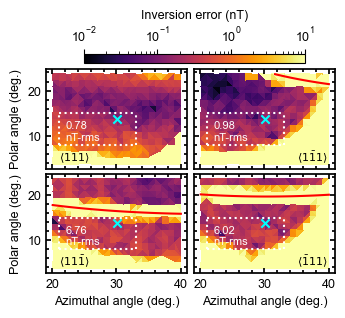

In [ ]:
import numpy as np

from bff_paper_figures.extract_experiment_values import (
    find_rabi_frequencies_from_signal,
    get_ideal_rabi_frequencies,
    get_true_transition_frequencies,
)
from bff_paper_figures.fitting_routines import (
    extract_fit_centers_all_orientations,
    fit_vs_eigenvalue_error_all_orientations_nt,
)
from bff_paper_figures.inner_product_functions import InnerProductSettings
from bff_paper_figures.inversions import (
    freq_domain_inversion,
    time_domain_inversion,
)
from bff_paper_figures.shared_parameters import (
    B_PHI_FIG4,
    B_THETA_FIG4,
    DETUNING_HZ,
    E_FIELD_VECTOR_V_PER_CM,
    MW_PHI,
    MW_THETA,
    PEAK_INDEX,
    RABI_FREQ_BASE_HZ,
    RAD_TO_DEGREE,
    RAMSEY_FREQ_RANGE_INITIAL_GUESS_HZ,
    T2STAR_S,
)
from bff_paper_figures.simulation_helper_functions import angles_already_evaluated, sq_cancelled_signal_generator
from bff_simulator.homogeneous_ensemble import HomogeneousEnsemble
from bff_simulator.liouvillian_solver import LiouvillianSolver
from bff_simulator.offaxis_field_experiment_parameters import OffAxisFieldExperimentParametersFactory

from matplotlib import pyplot as plt
from scipy.optimize import fsolve
from bff_simulator.constants import NVaxes_100
from bff_simulator.vector_manipulation import perpendicular_projection
from bff_paper_figures.Figure5_inversion import get_rms_error_within_range

NOMINAL_MW_THETA = 0.23957582149174544
NOMINAL_MW_PHI = 0.5244528089360776

MW_THETA_EXCURSION = 10 / RAD_TO_DEGREE
MW_PHI_EXCURSION = 10 / RAD_TO_DEGREE
MW_THETA_RANGE = np.linspace(MW_THETA - MW_THETA_EXCURSION, MW_THETA + MW_THETA_EXCURSION, 15)
MW_PHI_RANGE = np.linspace(MW_PHI - MW_PHI_EXCURSION, MW_PHI + MW_PHI_EXCURSION, 21)

B_MAGNITUDE_T = 50e-6
B_THETA = B_THETA_FIG4
B_PHI = B_PHI_FIG4

MW_PULSE_LENGTH_S = np.arange(0, 800e-9, 2.5e-9)
EVOLUTION_TIME_S = np.arange(0, 3e-6, 20e-9)

RABI_FREQ_BASE_HZ = 90e6
RABI_FREQ_RANGE_TO_PROBE_HZ = np.linspace(20e6, 150e6, 201)
HEIGHT_FACTOR = 0.3  # height factor for peak-finding
PROMINENCE_FACTOR = 0.3  # prominence factor for peak-finding

def rabi_difference_to_crosstalk_harmonic(
    theta: float, phi: float, crosstalk_orientation: int, harmonic: float, target_orientation: int
):
    mw_direction = np.array([np.cos(phi) * np.sin(theta), np.sin(phi) * np.sin(theta), np.cos(theta)])
    return harmonic * perpendicular_projection(
        NVaxes_100[crosstalk_orientation], mw_direction
    ) - perpendicular_projection(NVaxes_100[target_orientation], mw_direction)

# Define the experiment parameters except for MW direction
nv_ensemble = HomogeneousEnsemble()
nv_ensemble.t2_star_s = T2STAR_S
nv_ensemble.add_full_diamond_populations()

off_axis_solver = LiouvillianSolver()

exp_param_factory = OffAxisFieldExperimentParametersFactory()
exp_param_factory.set_base_rabi_frequency(RABI_FREQ_BASE_HZ)
exp_param_factory.set_e_field_v_per_m(E_FIELD_VECTOR_V_PER_CM)
exp_param_factory.set_detuning(DETUNING_HZ)
exp_param_factory.set_mw_pulse_lengths(MW_PULSE_LENGTH_S)
exp_param_factory.set_evolution_times(EVOLUTION_TIME_S)
exp_param_factory.set_b_field_vector(
    B_MAGNITUDE_T * np.array([np.sin(B_THETA) * np.cos(B_PHI), np.sin(B_THETA) * np.sin(B_PHI), np.cos(B_THETA)])
)

# Define the inner product settings for the inversion
inner_product_settings = InnerProductSettings(
    MW_PULSE_LENGTH_S,
    EVOLUTION_TIME_S,
    rabi_window="blackman",
    ramsey_window="boxcar",
    subtract_mean=True,
    use_effective_rabi_frequency=True,
)

# Lists in which we will store the angles at which we run the simulations along with the errors in
# extracted ms = +/-1 transition frequency for both frequency- and time-domain inversions
mw_theta_values = []
mw_phi_values = []
errors_freq_domain_nt = []
errors_time_domain_nt = []
problem_theta_values = []
problem_phi_values = []

for theta in MW_THETA_RANGE:
    for phi in MW_PHI_RANGE:
        # Check if we have already run the simulation for this angle - useful when loading partially completed
        # simultions
        if not angles_already_evaluated(theta, phi, mw_theta_values, mw_phi_values):
            # Find the new MW direction
            mw_direction = np.array([np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)])

            # Run the numerical experiment at this new MW direction
            exp_param_factory.set_mw_direction(mw_direction)
            sq_cancelled_signal = sq_cancelled_signal_generator(exp_param_factory, nv_ensemble, off_axis_solver)

            # Extract the true transition frequencies and true Rabi frequencies
            larmor_freqs_all_axes_hz, _ = get_true_transition_frequencies(exp_param_factory.get_experiment_parameters())
            ideal_rabi_frequencies = get_ideal_rabi_frequencies(exp_param_factory.get_experiment_parameters())
            print(f"Ideal Rabi frequencies: {np.array2string(ideal_rabi_frequencies * 1e-6, precision=2)}")

            try:
                # Extract Rabi frequencies from the data
                rabi_frequencies = find_rabi_frequencies_from_signal(sq_cancelled_signal, inner_product_settings, rabi_freq_range_to_probe_hz=RABI_FREQ_RANGE_TO_PROBE_HZ,
                height_factor=HEIGHT_FACTOR,
                prominence_factor=PROMINENCE_FACTOR,
                use_time_domain_summation_for_initial_guesses=False)
                print(f"Extracted Rabi frequencies: {np.array2string(rabi_frequencies * 1e-6, precision=2)}")

                # frequency domain inversion
                peakfit_results = freq_domain_inversion(
                    sq_cancelled_signal,
                    rabi_frequencies,
                    inner_product_settings,
                    RAMSEY_FREQ_RANGE_INITIAL_GUESS_HZ,
                    T2STAR_S,
                    constrain_same_width=True,
                    allow_zero_peak=True,
                )
                errors_freq_nt = fit_vs_eigenvalue_error_all_orientations_nt(peakfit_results, larmor_freqs_all_axes_hz)
                print(
                    f"theta = {RAD_TO_DEGREE * theta:.2f} deg, phi = {RAD_TO_DEGREE * phi:.2f} deg, freq domain errors = {np.array2string(errors_freq_nt[:, PEAK_INDEX], precision=2)} nT"
                )

                # time domain inversion
                freq_guesses_all_orientations = extract_fit_centers_all_orientations(peakfit_results)
                time_domain_fit_results = time_domain_inversion(
                    sq_cancelled_signal,
                    rabi_frequencies,
                    inner_product_settings,
                    freq_guesses_all_orientations,
                    T2STAR_S,
                    fix_phase_to_zero=False,
                    constrain_same_decay=True,
                    constrain_hyperfine_freqs=True,
                )
                errors_time_nt = fit_vs_eigenvalue_error_all_orientations_nt(
                    time_domain_fit_results, larmor_freqs_all_axes_hz
                )
                print(
                    f"\t \t \t time domain fit errors = {np.array2string(errors_time_nt[:, PEAK_INDEX], precision=3)} nT"
                )

                mw_theta_values.append(theta)
                mw_phi_values.append(phi)
                errors_freq_domain_nt.append(errors_freq_nt[:, PEAK_INDEX])
                errors_time_domain_nt.append(errors_time_nt[:, PEAK_INDEX])

            except (ValueError, IndexError):
                print(f"theta = {RAD_TO_DEGREE * theta:.2f}, phi = {RAD_TO_DEGREE * phi:.2f} MHz generated ValueError")
                problem_theta_values.append(theta)
                problem_phi_values.append(phi)


# Plot inversion error vs MW direction
errors_freq_vs_angle_nt = errors_freq_domain_nt
errors_time_vs_angle_nt = errors_time_domain_nt


# values of phi that will be used to calculate theta values where we expect large crosstalk
phi_crosstalk_rad = np.linspace(min(mw_phi_values), max(mw_phi_values), 51)

# define z axis of plot
plotstyle = "log"
vmin = 0.01
vmax = 10

# define labels and the positions at which they will be written
labels = [
    r"$\langle111\rangle$",
    r"$\langle1\bar{1}1\rangle$",
    r"$\langle11\bar{1}\rangle$",
    r"$\langle\bar{1}11\rangle$",
]
positions = [[21, 4.5], [35, 4.5], [21, 4.5], [35, 4.5]]


# Define the ranges over which we will calculate the RMS error
theta_ranges = [[8, 15], [8, 15], [8, 15], [8, 15]]
phi_ranges = [[21, 33], [21, 33], [21, 33], [21, 33]]

# Calculate the rms error and define how and where it should be plotted
errors = [
    get_rms_error_within_range(
        theta_ranges[i],
        phi_ranges[i],
        np.array(mw_phi_values),
        np.array(mw_theta_values),
        np.array(errors_time_vs_angle_nt),
        i,
    )
    for i in range(4)
]
error_labels = [f"{errors[i]:.2f}\nnT-rms" for i in range(4)]
error_positions = [[22, 9], [22, 9], [22, 9], [22, 9]]

# plot all orientations
plt.rcParams["font.size"] = 9
plt.rcParams["font.family"] = "arial"
fig, axes = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True)
fig.set_figheight(3)
fig.set_figwidth(3.4)
for i, ax in enumerate(axes.flat):
    im = ax.tripcolor(
        np.array(mw_phi_values) * RAD_TO_DEGREE,
        np.array(mw_theta_values) * RAD_TO_DEGREE,
        np.abs(np.array(errors_time_vs_angle_nt)[:, i]),
        cmap="inferno",
        norm=plotstyle,
        vmin=vmin,
        vmax=vmax,
    )

    # Add axis labels
    if i == 2 or i == 3:
        ax.set_xlabel("Azimuthal angle (deg.)", fontsize=9)
    if i == 0 or i == 2:
        ax.set_ylabel("Polar angle (deg.)", fontsize=9)

    # Plot the angle at which Fig. 6a is calculated
    ax.scatter(NOMINAL_MW_PHI * RAD_TO_DEGREE, NOMINAL_MW_THETA * RAD_TO_DEGREE, marker="x", color="cyan")

    # Add the orientation labels
    ax.text(positions[i][0], positions[i][1], labels[i], color="black", fontsize=8)

    # Beautify the ticks
    ax.yaxis.set_ticks_position("both")
    ax.xaxis.set_ticks_position("both")
    ax.minorticks_on()
    ax.tick_params(direction="in", which="both", width=1.25)
    ax.tick_params(direction="in", which="minor", length=2)
    ax.tick_params(direction="in", which="major", length=3.5)
    for spine in ax.spines.values():
        spine.set_linewidth(1.25)

    # Add in lines and rms errors
    ax.text(error_positions[i][0], error_positions[i][1], error_labels[i], color="white", fontsize=8)
    ax.vlines(phi_ranges[i], [theta_ranges[i][0]], [theta_ranges[i][1]], linestyle="dotted", color="white")
    ax.hlines(theta_ranges[i], [phi_ranges[i][0]], [phi_ranges[i][1]], linestyle="dotted", color="white")

    # Plot crosstalk
    if i > 0:
        # Find the angles at which the 3/2 harmonic of the <111> orientation intersects the rabi frequency of this orientation
        theta_crosstalk_rad = np.array(
            [fsolve(rabi_difference_to_crosstalk_harmonic, [0.5], (phi, 0, 1.5, i))[0] for phi in phi_crosstalk_rad]
        )

        # Only plot values that will actually fit in the plot
        mask = theta_crosstalk_rad < max(mw_theta_values)
        ax.plot(
            np.array(phi_crosstalk_rad)[mask] * RAD_TO_DEGREE, theta_crosstalk_rad[mask] * RAD_TO_DEGREE, color="red"
        )

# Adjust layout
plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.subplots_adjust(top=0.8, right=0.99, left=0.14, bottom=0.12)

# Add a shared colorbar
cbar_ax = fig.add_axes([0.25, 0.82, 0.65, 0.03])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Inversion error (nT)", fontsize=9)
cbar.ax.xaxis.set_label_position("top")
cbar.ax.xaxis.set_ticks_position("top")
plt.show()


### Simulation at 110 MHz Rabi

Ideal Rabi frequencies: [85.94 88.12 93.42 91.6 ]
Extracted Rabi frequencies: [85.98 88.23 93.6  91.58]
theta = 3.73 deg, phi = 20.05 deg, freq domain errors = [-25.96 -27.03 -24.81  -5.45] nT
	 	 	 time domain fit errors = [512.827 183.717  77.408 122.268] nT
Ideal Rabi frequencies: [85.9  88.19 93.44 91.53]
Extracted Rabi frequencies: [85.97 88.28 93.61 91.53]
theta = 3.73 deg, phi = 21.05 deg, freq domain errors = [-19.25 -20.15 -14.79   1.96] nT
	 	 	 time domain fit errors = [569.811 208.994  -0.823  53.264] nT
Ideal Rabi frequencies: [85.87 88.26 93.47 91.47]
Extracted Rabi frequencies: [85.95 88.34 93.62 91.49]
theta = 3.73 deg, phi = 22.05 deg, freq domain errors = [-15.31 -10.88  -3.69  12.19] nT
	 	 	 time domain fit errors = [571.654 215.908 -60.043   4.84 ] nT
Ideal Rabi frequencies: [85.84 88.33 93.49 91.41]
Extracted Rabi frequencies: [85.93 88.4  93.62 91.44]
theta = 3.73 deg, phi = 23.05 deg, freq domain errors = [-13.89   2.78   4.64  24.16] nT
	 	 	 time domain fit er

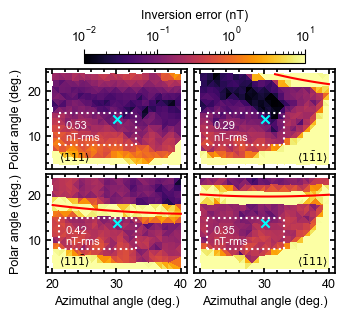

In [ ]:
import numpy as np

from bff_paper_figures.extract_experiment_values import (
    find_rabi_frequencies_from_signal,
    get_ideal_rabi_frequencies,
    get_true_transition_frequencies,
)
from bff_paper_figures.fitting_routines import (
    extract_fit_centers_all_orientations,
    fit_vs_eigenvalue_error_all_orientations_nt,
)
from bff_paper_figures.inner_product_functions import InnerProductSettings
from bff_paper_figures.inversions import (
    freq_domain_inversion,
    time_domain_inversion,
)
from bff_paper_figures.shared_parameters import (
    B_PHI_FIG4,
    B_THETA_FIG4,
    DETUNING_HZ,
    E_FIELD_VECTOR_V_PER_CM,
    MW_PHI,
    MW_THETA,
    PEAK_INDEX,
    RABI_FREQ_BASE_HZ,
    RAD_TO_DEGREE,
    RAMSEY_FREQ_RANGE_INITIAL_GUESS_HZ,
    T2STAR_S,
)
from bff_paper_figures.simulation_helper_functions import angles_already_evaluated, sq_cancelled_signal_generator
from bff_simulator.homogeneous_ensemble import HomogeneousEnsemble
from bff_simulator.liouvillian_solver import LiouvillianSolver
from bff_simulator.offaxis_field_experiment_parameters import OffAxisFieldExperimentParametersFactory

from matplotlib import pyplot as plt
from scipy.optimize import fsolve
from bff_simulator.constants import NVaxes_100
from bff_simulator.vector_manipulation import perpendicular_projection
from bff_paper_figures.Figure5_inversion import get_rms_error_within_range

NOMINAL_MW_THETA = 0.23957582149174544
NOMINAL_MW_PHI = 0.5244528089360776

MW_THETA_EXCURSION = 10 / RAD_TO_DEGREE
MW_PHI_EXCURSION = 10 / RAD_TO_DEGREE
MW_THETA_RANGE = np.linspace(MW_THETA - MW_THETA_EXCURSION, MW_THETA + MW_THETA_EXCURSION, 15)
MW_PHI_RANGE = np.linspace(MW_PHI - MW_PHI_EXCURSION, MW_PHI + MW_PHI_EXCURSION, 21)

B_MAGNITUDE_T = 50e-6
B_THETA = B_THETA_FIG4
B_PHI = B_PHI_FIG4

MW_PULSE_LENGTH_S = np.arange(0, 800e-9, 2.5e-9)
EVOLUTION_TIME_S = np.arange(0, 3e-6, 20e-9)

RABI_FREQ_BASE_HZ = 110e6
RABI_FREQ_RANGE_TO_PROBE_HZ = np.linspace(20e6, 150e6, 201)
HEIGHT_FACTOR = 0.3  # height factor for peak-finding
PROMINENCE_FACTOR = 0.3  # prominence factor for peak-finding

def rabi_difference_to_crosstalk_harmonic(
    theta: float, phi: float, crosstalk_orientation: int, harmonic: float, target_orientation: int
):
    mw_direction = np.array([np.cos(phi) * np.sin(theta), np.sin(phi) * np.sin(theta), np.cos(theta)])
    return harmonic * perpendicular_projection(
        NVaxes_100[crosstalk_orientation], mw_direction
    ) - perpendicular_projection(NVaxes_100[target_orientation], mw_direction)

# Define the experiment parameters except for MW direction
nv_ensemble = HomogeneousEnsemble()
nv_ensemble.t2_star_s = T2STAR_S
nv_ensemble.add_full_diamond_populations()

off_axis_solver = LiouvillianSolver()

exp_param_factory = OffAxisFieldExperimentParametersFactory()
exp_param_factory.set_base_rabi_frequency(RABI_FREQ_BASE_HZ)
exp_param_factory.set_e_field_v_per_m(E_FIELD_VECTOR_V_PER_CM)
exp_param_factory.set_detuning(DETUNING_HZ)
exp_param_factory.set_mw_pulse_lengths(MW_PULSE_LENGTH_S)
exp_param_factory.set_evolution_times(EVOLUTION_TIME_S)
exp_param_factory.set_b_field_vector(
    B_MAGNITUDE_T * np.array([np.sin(B_THETA) * np.cos(B_PHI), np.sin(B_THETA) * np.sin(B_PHI), np.cos(B_THETA)])
)

# Define the inner product settings for the inversion
inner_product_settings = InnerProductSettings(
    MW_PULSE_LENGTH_S,
    EVOLUTION_TIME_S,
    rabi_window="blackman",
    ramsey_window="boxcar",
    subtract_mean=True,
    use_effective_rabi_frequency=True,
)

# Lists in which we will store the angles at which we run the simulations along with the errors in
# extracted ms = +/-1 transition frequency for both frequency- and time-domain inversions
mw_theta_values = []
mw_phi_values = []
errors_freq_domain_nt = []
errors_time_domain_nt = []
problem_theta_values = []
problem_phi_values = []

for theta in MW_THETA_RANGE:
    for phi in MW_PHI_RANGE:
        # Check if we have already run the simulation for this angle - useful when loading partially completed
        # simultions
        if not angles_already_evaluated(theta, phi, mw_theta_values, mw_phi_values):
            # Find the new MW direction
            mw_direction = np.array([np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)])

            # Run the numerical experiment at this new MW direction
            exp_param_factory.set_mw_direction(mw_direction)
            sq_cancelled_signal = sq_cancelled_signal_generator(exp_param_factory, nv_ensemble, off_axis_solver)

            # Extract the true transition frequencies and true Rabi frequencies
            larmor_freqs_all_axes_hz, _ = get_true_transition_frequencies(exp_param_factory.get_experiment_parameters())
            ideal_rabi_frequencies = get_ideal_rabi_frequencies(exp_param_factory.get_experiment_parameters())
            print(f"Ideal Rabi frequencies: {np.array2string(ideal_rabi_frequencies * 1e-6, precision=2)}")

            try:
                # Extract Rabi frequencies from the data
                rabi_frequencies = find_rabi_frequencies_from_signal(sq_cancelled_signal, inner_product_settings, rabi_freq_range_to_probe_hz=RABI_FREQ_RANGE_TO_PROBE_HZ,
                height_factor=HEIGHT_FACTOR,
                prominence_factor=PROMINENCE_FACTOR,
                use_time_domain_summation_for_initial_guesses=False)
                print(f"Extracted Rabi frequencies: {np.array2string(rabi_frequencies * 1e-6, precision=2)}")

                # frequency domain inversion
                peakfit_results = freq_domain_inversion(
                    sq_cancelled_signal,
                    rabi_frequencies,
                    inner_product_settings,
                    RAMSEY_FREQ_RANGE_INITIAL_GUESS_HZ,
                    T2STAR_S,
                    constrain_same_width=True,
                    allow_zero_peak=True,
                )
                errors_freq_nt = fit_vs_eigenvalue_error_all_orientations_nt(peakfit_results, larmor_freqs_all_axes_hz)
                print(
                    f"theta = {RAD_TO_DEGREE * theta:.2f} deg, phi = {RAD_TO_DEGREE * phi:.2f} deg, freq domain errors = {np.array2string(errors_freq_nt[:, PEAK_INDEX], precision=2)} nT"
                )

                # time domain inversion
                freq_guesses_all_orientations = extract_fit_centers_all_orientations(peakfit_results)
                time_domain_fit_results = time_domain_inversion(
                    sq_cancelled_signal,
                    rabi_frequencies,
                    inner_product_settings,
                    freq_guesses_all_orientations,
                    T2STAR_S,
                    fix_phase_to_zero=False,
                    constrain_same_decay=True,
                    constrain_hyperfine_freqs=True,
                )
                errors_time_nt = fit_vs_eigenvalue_error_all_orientations_nt(
                    time_domain_fit_results, larmor_freqs_all_axes_hz
                )
                print(
                    f"\t \t \t time domain fit errors = {np.array2string(errors_time_nt[:, PEAK_INDEX], precision=3)} nT"
                )

                mw_theta_values.append(theta)
                mw_phi_values.append(phi)
                errors_freq_domain_nt.append(errors_freq_nt[:, PEAK_INDEX])
                errors_time_domain_nt.append(errors_time_nt[:, PEAK_INDEX])

            except (ValueError, IndexError):
                print(f"theta = {RAD_TO_DEGREE * theta:.2f}, phi = {RAD_TO_DEGREE * phi:.2f} MHz generated ValueError")
                problem_theta_values.append(theta)
                problem_phi_values.append(phi)


# Plot inversion error vs MW direction
errors_freq_vs_angle_nt = errors_freq_domain_nt
errors_time_vs_angle_nt = errors_time_domain_nt


# values of phi that will be used to calculate theta values where we expect large crosstalk
phi_crosstalk_rad = np.linspace(min(mw_phi_values), max(mw_phi_values), 51)

# define z axis of plot
plotstyle = "log"
vmin = 0.01
vmax = 10

# define labels and the positions at which they will be written
labels = [
    r"$\langle111\rangle$",
    r"$\langle1\bar{1}1\rangle$",
    r"$\langle11\bar{1}\rangle$",
    r"$\langle\bar{1}11\rangle$",
]
positions = [[21, 4.5], [35, 4.5], [21, 4.5], [35, 4.5]]


# Define the ranges over which we will calculate the RMS error
theta_ranges = [[8, 15], [8, 15], [8, 15], [8, 15]]
phi_ranges = [[21, 33], [21, 33], [21, 33], [21, 33]]

# Calculate the rms error and define how and where it should be plotted
errors = [
    get_rms_error_within_range(
        theta_ranges[i],
        phi_ranges[i],
        np.array(mw_phi_values),
        np.array(mw_theta_values),
        np.array(errors_time_vs_angle_nt),
        i,
    )
    for i in range(4)
]
error_labels = [f"{errors[i]:.2f}\nnT-rms" for i in range(4)]
error_positions = [[22, 9], [22, 9], [22, 9], [22, 9]]

# plot all orientations
plt.rcParams["font.size"] = 9
plt.rcParams["font.family"] = "arial"
fig, axes = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True)
fig.set_figheight(3)
fig.set_figwidth(3.4)
for i, ax in enumerate(axes.flat):
    im = ax.tripcolor(
        np.array(mw_phi_values) * RAD_TO_DEGREE,
        np.array(mw_theta_values) * RAD_TO_DEGREE,
        np.abs(np.array(errors_time_vs_angle_nt)[:, i]),
        cmap="inferno",
        norm=plotstyle,
        vmin=vmin,
        vmax=vmax,
    )

    # Add axis labels
    if i == 2 or i == 3:
        ax.set_xlabel("Azimuthal angle (deg.)", fontsize=9)
    if i == 0 or i == 2:
        ax.set_ylabel("Polar angle (deg.)", fontsize=9)

    # Plot the angle at which Fig. 6a is calculated
    ax.scatter(NOMINAL_MW_PHI * RAD_TO_DEGREE, NOMINAL_MW_THETA * RAD_TO_DEGREE, marker="x", color="cyan")

    # Add the orientation labels
    ax.text(positions[i][0], positions[i][1], labels[i], color="black", fontsize=8)

    # Beautify the ticks
    ax.yaxis.set_ticks_position("both")
    ax.xaxis.set_ticks_position("both")
    ax.minorticks_on()
    ax.tick_params(direction="in", which="both", width=1.25)
    ax.tick_params(direction="in", which="minor", length=2)
    ax.tick_params(direction="in", which="major", length=3.5)
    for spine in ax.spines.values():
        spine.set_linewidth(1.25)

    # Add in lines and rms errors
    ax.text(error_positions[i][0], error_positions[i][1], error_labels[i], color="white", fontsize=8)
    ax.vlines(phi_ranges[i], [theta_ranges[i][0]], [theta_ranges[i][1]], linestyle="dotted", color="white")
    ax.hlines(theta_ranges[i], [phi_ranges[i][0]], [phi_ranges[i][1]], linestyle="dotted", color="white")

    # Plot crosstalk
    if i > 0:
        # Find the angles at which the 3/2 harmonic of the <111> orientation intersects the rabi frequency of this orientation
        theta_crosstalk_rad = np.array(
            [fsolve(rabi_difference_to_crosstalk_harmonic, [0.5], (phi, 0, 1.5, i))[0] for phi in phi_crosstalk_rad]
        )

        # Only plot values that will actually fit in the plot
        mask = theta_crosstalk_rad < max(mw_theta_values)
        ax.plot(
            np.array(phi_crosstalk_rad)[mask] * RAD_TO_DEGREE, theta_crosstalk_rad[mask] * RAD_TO_DEGREE, color="red"
        )

# Adjust layout
plt.subplots_adjust(wspace=0.05, hspace=0.05)
plt.subplots_adjust(top=0.8, right=0.99, left=0.14, bottom=0.12)

# Add a shared colorbar
cbar_ax = fig.add_axes([0.25, 0.82, 0.65, 0.03])
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label("Inversion error (nT)", fontsize=9)
cbar.ax.xaxis.set_label_position("top")
cbar.ax.xaxis.set_ticks_position("top")
plt.show()


### Testing Fig 6 at 20 uT

#### Script for running 6a with everything defined

In [1]:
import numpy as np

from bff_paper_figures.extract_experiment_values import (
    find_rabi_frequencies_from_signal,
    get_ideal_rabi_frequencies,
    get_true_transition_frequencies,
)
from bff_paper_figures.fitting_routines import (
    extract_fit_centers_all_orientations,
    fit_vs_eigenvalue_error_all_orientations_nt,
)
from bff_paper_figures.inner_product_functions import InnerProductSettings
from bff_paper_figures.inversions import (
    freq_domain_inversion,
    time_domain_inversion,
)
from bff_paper_figures.shared_parameters import (
    B_PHI_FIG4,
    B_THETA_FIG4,
    DETUNING_HZ,
    E_FIELD_VECTOR_V_PER_CM,
    MW_DIRECTION,
    PEAK_INDEX,
    RAMSEY_FREQ_RANGE_INITIAL_GUESS_HZ,
    T2STAR_S,
)
from bff_paper_figures.simulation_helper_functions import sq_cancelled_signal_generator
from bff_simulator.homogeneous_ensemble import HomogeneousEnsemble
from bff_simulator.liouvillian_solver import LiouvillianSolver
from bff_simulator.offaxis_field_experiment_parameters import OffAxisFieldExperimentParametersFactory

RABI_MAX_RANGE = np.linspace(50e6, 150e6, 51)

MW_PULSE_LENGTH_S = np.arange(0, 800e-9, 2.5e-9)  # np.linspace(0, 0.5e-6, 1001)
EVOLUTION_TIME_S = np.arange(0, 3e-6, 20e-9)  # p.linspace(0, 15e-6, 801)

# The range of rabi frequencies over which we will evaluate the free-evolution-time-summed inner product in order
# to get initial guesses for the orientations' rabi frequencies via peakfinding
RABI_FREQ_RANGE_TO_PROBE_HZ = np.linspace(20e6, 150e6, 201)
HEIGHT_FACTOR = 0.3  # height factor for peak-finding
PROMINENCE_FACTOR = 0.3  # prominence factor for peak-finding

RUN_LABEL = f"rabi_{min(RABI_MAX_RANGE) * 1e-6:.02f}_to_{max(RABI_MAX_RANGE) * 1e-6:.02f}_mhz"

def run_fig_6a(B_MAGNITUDE_T):
    B_THETA = B_THETA_FIG4
    B_PHI = B_PHI_FIG4
    B_FIELD_VECTOR_T = B_MAGNITUDE_T * np.array(
        [np.sin(B_THETA) * np.cos(B_PHI), np.sin(B_THETA) * np.sin(B_PHI), np.cos(B_THETA)]
    )
    # Set up simulation for everything except maximum Rabi frequency
    nv_ensemble = HomogeneousEnsemble()
    nv_ensemble.t2_star_s = T2STAR_S
    nv_ensemble.add_full_diamond_populations()

    off_axis_solver = LiouvillianSolver()

    exp_param_factory = OffAxisFieldExperimentParametersFactory()
    exp_param_factory.set_mw_direction(MW_DIRECTION)
    exp_param_factory.set_e_field_v_per_m(E_FIELD_VECTOR_V_PER_CM)
    exp_param_factory.set_detuning(DETUNING_HZ)
    exp_param_factory.set_mw_pulse_lengths(MW_PULSE_LENGTH_S)
    exp_param_factory.set_evolution_times(EVOLUTION_TIME_S)
    exp_param_factory.set_b_field_vector(B_FIELD_VECTOR_T)

    inner_product_settings = InnerProductSettings(
        MW_PULSE_LENGTH_S,
        EVOLUTION_TIME_S,
        rabi_window="blackman",
        ramsey_window="boxcar",
        subtract_mean=True,
        use_effective_rabi_frequency=True,
    )

    rabi_maxes = []
    errors_freq_nt = []
    errors_time_nt = []

    for rabi_max in RABI_MAX_RANGE:
        if rabi_max not in rabi_maxes:
            # Run the experiment at a different Rabi frequency (corresponding to e.g. amplifier drift) and calculate the signal
            exp_param_factory.set_base_rabi_frequency(rabi_max)
            sq_cancelled_signal = sq_cancelled_signal_generator(exp_param_factory, nv_ensemble, off_axis_solver)

            # Use the "ground truth" hamiltonian to calculate the transition frequencies we wish to extract, as well as
            # the "ground truth" rabi frequencies for each
            dq_larmor_freqs_all_axes_hz, bz_values_all_axes_t = get_true_transition_frequencies(
                exp_param_factory.get_experiment_parameters()
            )
            ideal_rabi_frequencies = get_ideal_rabi_frequencies(exp_param_factory.get_experiment_parameters())
            print(f"Ideal Rabi frequencies: {np.array2string(ideal_rabi_frequencies * 1e-6, precision=2)}")

            try:
                # Run the analysis using the rabi frequency extracted from the signal
                rabi_frequencies = find_rabi_frequencies_from_signal(
                    sq_cancelled_signal,
                    inner_product_settings,
                    rabi_freq_range_to_probe_hz=RABI_FREQ_RANGE_TO_PROBE_HZ,
                    height_factor=HEIGHT_FACTOR,
                    prominence_factor=PROMINENCE_FACTOR,
                    use_time_domain_summation_for_initial_guesses=False,
                )
                print(f"Extracted Rabi frequencies: {np.array2string(rabi_frequencies * 1e-6, precision=2)}")

                # frequency domain inversion
                peakfit_results = freq_domain_inversion(
                    sq_cancelled_signal,
                    rabi_frequencies,
                    inner_product_settings,
                    RAMSEY_FREQ_RANGE_INITIAL_GUESS_HZ,
                    T2STAR_S,
                    constrain_same_width=True,
                    allow_zero_peak=True,
                )
                errors_fd_nt = fit_vs_eigenvalue_error_all_orientations_nt(peakfit_results, dq_larmor_freqs_all_axes_hz)
                print(
                    f"Rabi_max = {1e-6 * rabi_max:.2f} MHz, freq domain errors = {np.array2string(errors_fd_nt[:, PEAK_INDEX], precision=2)} nT"
                )

                # time domain inversion using results from frequency domain inversion as an initial guess
                freq_guesses_all_orientations = extract_fit_centers_all_orientations(peakfit_results)
                time_domain_fit_results = time_domain_inversion(
                    sq_cancelled_signal,
                    rabi_frequencies,
                    inner_product_settings,
                    freq_guesses_all_orientations,
                    T2STAR_S,
                    fix_phase_to_zero=False,
                    constrain_same_decay=True,
                    constrain_hyperfine_freqs=True,
                )

                # Compare extracted transition frequencies to the ideal values
                errors_td_nt = fit_vs_eigenvalue_error_all_orientations_nt(
                    time_domain_fit_results, dq_larmor_freqs_all_axes_hz
                )
                print(f"\t \t \t time domain fit errors = {np.array2string(errors_td_nt[:, PEAK_INDEX], precision=3)} nT")

                rabi_maxes.append(rabi_max)
                errors_freq_nt.append(errors_fd_nt[:, PEAK_INDEX])
                errors_time_nt.append(errors_td_nt[:, PEAK_INDEX])

            except ValueError:
                print(f"Rabi_max = {1e-6 * rabi_max:.2f} MHz generated ValueError ")

    # Plot the data
    plt.figure(0, figsize=(3.4, 2))
    plt.rcParams["font.size"] = 9
    plt.rcParams["font.family"] = "arial"

    labels = [
        r"$\langle111\rangle$",
        r"$\langle1\bar{1}1\rangle$",
        r"$\langle11\bar{1}\rangle$",
        r"$\langle\bar{1}11\rangle$",
    ]
    plt.plot(1e-6 * np.array(rabi_maxes), errors_time_nt, label=labels)
    plt.legend(loc="lower right", ncol=2)
    plt.xlabel(r"$\Omega_\text{max}/2\pi$ (MHz)")
    plt.ylabel("Inversion error (nT)")
    plt.gca().yaxis.set_ticks_position("both")
    plt.gca().xaxis.set_ticks_position("both")
    plt.gca().minorticks_on()
    plt.gca().tick_params(direction="in", which="both", width=1.5)
    plt.gca().tick_params(direction="in", which="minor", length=2.5)
    plt.gca().tick_params(direction="in", which="major", length=5)
    for spine in plt.gca().spines.values():
        spine.set_linewidth(1.25)
    plt.ylim((-2, 2))
    plt.tight_layout()
    plt.show()



#### Script for running 6b with everything defined

In [2]:
import numpy as np

from bff_paper_figures.extract_experiment_values import (
    find_rabi_frequencies_from_signal,
    get_ideal_rabi_frequencies,
    get_true_transition_frequencies,
)
from bff_paper_figures.fitting_routines import (
    extract_fit_centers_all_orientations,
    fit_vs_eigenvalue_error_all_orientations_nt,
)
from bff_paper_figures.inner_product_functions import InnerProductSettings
from bff_paper_figures.inversions import (
    freq_domain_inversion,
    time_domain_inversion,
)
from bff_paper_figures.shared_parameters import (
    B_PHI_FIG4,
    B_THETA_FIG4,
    DETUNING_HZ,
    E_FIELD_VECTOR_V_PER_CM,
    MW_PHI,
    MW_THETA,
    PEAK_INDEX,
    RABI_FREQ_BASE_HZ,
    RAD_TO_DEGREE,
    RAMSEY_FREQ_RANGE_INITIAL_GUESS_HZ,
    T2STAR_S,
)
from bff_paper_figures.simulation_helper_functions import angles_already_evaluated, sq_cancelled_signal_generator
from bff_simulator.homogeneous_ensemble import HomogeneousEnsemble
from bff_simulator.liouvillian_solver import LiouvillianSolver
from bff_simulator.offaxis_field_experiment_parameters import OffAxisFieldExperimentParametersFactory

from matplotlib import pyplot as plt
from scipy.optimize import fsolve
from bff_simulator.constants import NVaxes_100
from bff_simulator.vector_manipulation import perpendicular_projection
from bff_paper_figures.Figure5_inversion import get_rms_error_within_range

NOMINAL_MW_THETA = 0.23957582149174544
NOMINAL_MW_PHI = 0.5244528089360776

MW_THETA_EXCURSION = 10 / RAD_TO_DEGREE
MW_PHI_EXCURSION = 10 / RAD_TO_DEGREE
MW_THETA_RANGE = np.linspace(MW_THETA - MW_THETA_EXCURSION, MW_THETA + MW_THETA_EXCURSION, 15)
MW_PHI_RANGE = np.linspace(MW_PHI - MW_PHI_EXCURSION, MW_PHI + MW_PHI_EXCURSION, 21)

B_THETA = B_THETA_FIG4
B_PHI = B_PHI_FIG4

MW_PULSE_LENGTH_S = np.arange(0, 800e-9, 2.5e-9)
EVOLUTION_TIME_S = np.arange(0, 3e-6, 20e-9)

RABI_FREQ_BASE_HZ = 110e6
RABI_FREQ_RANGE_TO_PROBE_HZ = np.linspace(20e6, 150e6, 201)
HEIGHT_FACTOR = 0.3  # height factor for peak-finding
PROMINENCE_FACTOR = 0.3  # prominence factor for peak-finding

def rabi_difference_to_crosstalk_harmonic(
    theta: float, phi: float, crosstalk_orientation: int, harmonic: float, target_orientation: int
):
    mw_direction = np.array([np.cos(phi) * np.sin(theta), np.sin(phi) * np.sin(theta), np.cos(theta)])
    return harmonic * perpendicular_projection(
        NVaxes_100[crosstalk_orientation], mw_direction
    ) - perpendicular_projection(NVaxes_100[target_orientation], mw_direction)

def run_fig_6b(b_magnitude_t=50e-6, detuning_hz=0):
    # Define the experiment parameters except for MW direction
    nv_ensemble = HomogeneousEnsemble()
    nv_ensemble.t2_star_s = T2STAR_S
    nv_ensemble.add_full_diamond_populations()

    off_axis_solver = LiouvillianSolver()

    exp_param_factory = OffAxisFieldExperimentParametersFactory()
    exp_param_factory.set_base_rabi_frequency(RABI_FREQ_BASE_HZ)
    exp_param_factory.set_e_field_v_per_m(E_FIELD_VECTOR_V_PER_CM)
    exp_param_factory.set_detuning(detuning_hz)
    exp_param_factory.set_mw_pulse_lengths(MW_PULSE_LENGTH_S)
    exp_param_factory.set_evolution_times(EVOLUTION_TIME_S)
    exp_param_factory.set_b_field_vector(
        b_magnitude_t * np.array([np.sin(B_THETA) * np.cos(B_PHI), np.sin(B_THETA) * np.sin(B_PHI), np.cos(B_THETA)])
    )

    # Define the inner product settings for the inversion
    inner_product_settings = InnerProductSettings(
        MW_PULSE_LENGTH_S,
        EVOLUTION_TIME_S,
        rabi_window="blackman",
        ramsey_window="boxcar",
        subtract_mean=True,
        use_effective_rabi_frequency=True,
    )

    # Lists in which we will store the angles at which we run the simulations along with the errors in
    # extracted ms = +/-1 transition frequency for both frequency- and time-domain inversions
    mw_theta_values = []
    mw_phi_values = []
    errors_freq_domain_nt = []
    errors_time_domain_nt = []
    problem_theta_values = []
    problem_phi_values = []

    for theta in MW_THETA_RANGE:
        for phi in MW_PHI_RANGE:
            # Check if we have already run the simulation for this angle - useful when loading partially completed
            # simultions
            if not angles_already_evaluated(theta, phi, mw_theta_values, mw_phi_values):
                # Find the new MW direction
                mw_direction = np.array([np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)])

                # Run the numerical experiment at this new MW direction
                exp_param_factory.set_mw_direction(mw_direction)
                sq_cancelled_signal = sq_cancelled_signal_generator(exp_param_factory, nv_ensemble, off_axis_solver)

                # Extract the true transition frequencies and true Rabi frequencies
                larmor_freqs_all_axes_hz, _ = get_true_transition_frequencies(exp_param_factory.get_experiment_parameters())
                ideal_rabi_frequencies = get_ideal_rabi_frequencies(exp_param_factory.get_experiment_parameters())
                print(f"Ideal Rabi frequencies: {np.array2string(ideal_rabi_frequencies * 1e-6, precision=2)}")

                try:
                    # Extract Rabi frequencies from the data
                    rabi_frequencies = find_rabi_frequencies_from_signal(sq_cancelled_signal, inner_product_settings, rabi_freq_range_to_probe_hz=RABI_FREQ_RANGE_TO_PROBE_HZ,
                    height_factor=HEIGHT_FACTOR,
                    prominence_factor=PROMINENCE_FACTOR,
                    use_time_domain_summation_for_initial_guesses=False)
                    print(f"Extracted Rabi frequencies: {np.array2string(rabi_frequencies * 1e-6, precision=2)}")

                    # frequency domain inversion
                    peakfit_results = freq_domain_inversion(
                        sq_cancelled_signal,
                        rabi_frequencies,
                        inner_product_settings,
                        RAMSEY_FREQ_RANGE_INITIAL_GUESS_HZ,
                        T2STAR_S,
                        constrain_same_width=True,
                        allow_zero_peak=True,
                    )
                    errors_freq_nt = fit_vs_eigenvalue_error_all_orientations_nt(peakfit_results, larmor_freqs_all_axes_hz)
                    print(
                        f"theta = {RAD_TO_DEGREE * theta:.2f} deg, phi = {RAD_TO_DEGREE * phi:.2f} deg, freq domain errors = {np.array2string(errors_freq_nt[:, PEAK_INDEX], precision=2)} nT"
                    )

                    # time domain inversion
                    freq_guesses_all_orientations = extract_fit_centers_all_orientations(peakfit_results)
                    time_domain_fit_results = time_domain_inversion(
                        sq_cancelled_signal,
                        rabi_frequencies,
                        inner_product_settings,
                        freq_guesses_all_orientations,
                        T2STAR_S,
                        fix_phase_to_zero=False,
                        constrain_same_decay=True,
                        constrain_hyperfine_freqs=True,
                    )
                    errors_time_nt = fit_vs_eigenvalue_error_all_orientations_nt(
                        time_domain_fit_results, larmor_freqs_all_axes_hz
                    )
                    print(
                        f"\t \t \t time domain fit errors = {np.array2string(errors_time_nt[:, PEAK_INDEX], precision=3)} nT"
                    )

                    mw_theta_values.append(theta)
                    mw_phi_values.append(phi)
                    errors_freq_domain_nt.append(errors_freq_nt[:, PEAK_INDEX])
                    errors_time_domain_nt.append(errors_time_nt[:, PEAK_INDEX])

                except (ValueError, IndexError):
                    print(f"theta = {RAD_TO_DEGREE * theta:.2f}, phi = {RAD_TO_DEGREE * phi:.2f} MHz generated ValueError")
                    problem_theta_values.append(theta)
                    problem_phi_values.append(phi)


    # Plot inversion error vs MW direction
    errors_freq_vs_angle_nt = errors_freq_domain_nt
    errors_time_vs_angle_nt = errors_time_domain_nt


    # values of phi that will be used to calculate theta values where we expect large crosstalk
    phi_crosstalk_rad = np.linspace(min(mw_phi_values), max(mw_phi_values), 51)

    # define z axis of plot
    plotstyle = "log"
    vmin = 0.01
    vmax = 10

    # define labels and the positions at which they will be written
    labels = [
        r"$\langle111\rangle$",
        r"$\langle1\bar{1}1\rangle$",
        r"$\langle11\bar{1}\rangle$",
        r"$\langle\bar{1}11\rangle$",
    ]
    positions = [[21, 4.5], [35, 4.5], [21, 4.5], [35, 4.5]]


    # Define the ranges over which we will calculate the RMS error
    theta_ranges = [[8, 15], [8, 15], [8, 15], [8, 15]]
    phi_ranges = [[21, 33], [21, 33], [21, 33], [21, 33]]

    # Calculate the rms error and define how and where it should be plotted
    errors = [
        get_rms_error_within_range(
            theta_ranges[i],
            phi_ranges[i],
            np.array(mw_phi_values),
            np.array(mw_theta_values),
            np.array(errors_time_vs_angle_nt),
            i,
        )
        for i in range(4)
    ]
    error_labels = [f"{errors[i]:.2f}\nnT-rms" for i in range(4)]
    error_positions = [[22, 9], [22, 9], [22, 9], [22, 9]]

    # plot all orientations
    plt.rcParams["font.size"] = 9
    plt.rcParams["font.family"] = "arial"
    fig, axes = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True)
    fig.set_figheight(3)
    fig.set_figwidth(3.4)
    for i, ax in enumerate(axes.flat):
        im = ax.tripcolor(
            np.array(mw_phi_values) * RAD_TO_DEGREE,
            np.array(mw_theta_values) * RAD_TO_DEGREE,
            np.abs(np.array(errors_time_vs_angle_nt)[:, i]),
            cmap="inferno",
            norm=plotstyle,
            vmin=vmin,
            vmax=vmax,
        )

        # Add axis labels
        if i == 2 or i == 3:
            ax.set_xlabel("Azimuthal angle (deg.)", fontsize=9)
        if i == 0 or i == 2:
            ax.set_ylabel("Polar angle (deg.)", fontsize=9)

        # Plot the angle at which Fig. 6a is calculated
        ax.scatter(NOMINAL_MW_PHI * RAD_TO_DEGREE, NOMINAL_MW_THETA * RAD_TO_DEGREE, marker="x", color="cyan")

        # Add the orientation labels
        ax.text(positions[i][0], positions[i][1], labels[i], color="black", fontsize=8)

        # Beautify the ticks
        ax.yaxis.set_ticks_position("both")
        ax.xaxis.set_ticks_position("both")
        ax.minorticks_on()
        ax.tick_params(direction="in", which="both", width=1.25)
        ax.tick_params(direction="in", which="minor", length=2)
        ax.tick_params(direction="in", which="major", length=3.5)
        for spine in ax.spines.values():
            spine.set_linewidth(1.25)

        # Add in lines and rms errors
        ax.text(error_positions[i][0], error_positions[i][1], error_labels[i], color="white", fontsize=8)
        ax.vlines(phi_ranges[i], [theta_ranges[i][0]], [theta_ranges[i][1]], linestyle="dotted", color="white")
        ax.hlines(theta_ranges[i], [phi_ranges[i][0]], [phi_ranges[i][1]], linestyle="dotted", color="white")

        # Plot crosstalk
        if i > 0:
            # Find the angles at which the 3/2 harmonic of the <111> orientation intersects the rabi frequency of this orientation
            theta_crosstalk_rad = np.array(
                [fsolve(rabi_difference_to_crosstalk_harmonic, [0.5], (phi, 0, 1.5, i))[0] for phi in phi_crosstalk_rad]
            )

            # Only plot values that will actually fit in the plot
            mask = theta_crosstalk_rad < max(mw_theta_values)
            ax.plot(
                np.array(phi_crosstalk_rad)[mask] * RAD_TO_DEGREE, theta_crosstalk_rad[mask] * RAD_TO_DEGREE, color="red"
            )

    # Adjust layout
    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    plt.subplots_adjust(top=0.8, right=0.99, left=0.14, bottom=0.12)

    # Add a shared colorbar
    cbar_ax = fig.add_axes([0.25, 0.82, 0.65, 0.03])
    cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
    cbar.set_label("Inversion error (nT)", fontsize=9)
    cbar.ax.xaxis.set_label_position("top")
    cbar.ax.xaxis.set_ticks_position("top")
    plt.show()

#### Fig 6 at 20 uT

Ideal Rabi frequencies: [33.18 39.59 46.38 42.98]
Extracted Rabi frequencies: [33.38 39.75 46.51 43.13]
Rabi_max = 50.00 MHz, freq domain errors = [424.98 -28.7   26.2  -50.05] nT
	 	 	 time domain fit errors = [ -1.476  -6.282 -10.493  12.939] nT
Ideal Rabi frequencies: [34.51 41.17 48.23 44.7 ]
Extracted Rabi frequencies: [34.7  41.32 48.36 44.85]
Rabi_max = 52.00 MHz, freq domain errors = [387.14 -29.42  25.92 -48.54] nT
	 	 	 time domain fit errors = [-6.01  -3.184 -4.344  5.67 ] nT
Ideal Rabi frequencies: [35.84 42.75 50.09 46.42]
Extracted Rabi frequencies: [36.02 42.9  50.21 46.56]
Rabi_max = 54.00 MHz, freq domain errors = [351.64 -30.74  25.1  -47.23] nT
	 	 	 time domain fit errors = [-1.743 -1.6   -2.287  3.103] nT
Ideal Rabi frequencies: [37.16 44.34 51.94 48.14]
Extracted Rabi frequencies: [37.34 44.47 52.06 48.27]
Rabi_max = 56.00 MHz, freq domain errors = [322.55 -28.69  24.24 -42.91] nT
	 	 	 time domain fit errors = [ 4.194 -0.333 -1.51   2.037] nT
Ideal Rabi frequenci

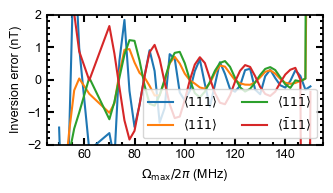

In [14]:
run_fig_6a(B_MAGNITUDE_T= 20e-6)

Ideal Rabi frequencies: [85.94 88.12 93.42 91.6 ]
Extracted Rabi frequencies: [85.98 88.22 93.6  91.56]
theta = 3.73 deg, phi = 20.05 deg, freq domain errors = [354.35 -86.33  22.16  27.51] nT
	 	 	 time domain fit errors = [1465.826  223.735  153.604  -99.873] nT
Ideal Rabi frequencies: [85.9  88.19 93.44 91.53]
Extracted Rabi frequencies: [85.97 88.27 93.6  91.51]
theta = 3.73 deg, phi = 21.05 deg, freq domain errors = [483.36 -84.7   25.5    8.63] nT
	 	 	 time domain fit errors = [1465.449  248.878   -3.952   24.394] nT
Ideal Rabi frequencies: [85.87 88.26 93.47 91.47]
Extracted Rabi frequencies: [85.95 88.33 93.61 91.47]
theta = 3.73 deg, phi = 22.05 deg, freq domain errors = [584.74 -76.72  28.46 -11.67] nT
	 	 	 time domain fit errors = [1465.306  245.927 -127.284  122.772] nT
Ideal Rabi frequencies: [85.84 88.33 93.49 91.41]
Extracted Rabi frequencies: [85.93 88.4  93.61 91.42]
theta = 3.73 deg, phi = 23.05 deg, freq domain errors = [605.45 -62.3   30.72 -27.62] nT
	 	 	 time d

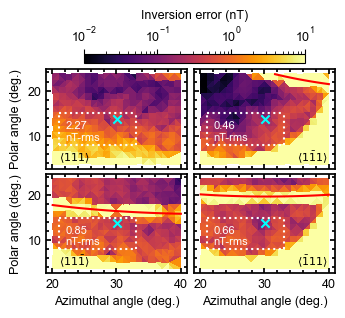

In [3]:
run_fig_6b(b_magnitude_t=20e-6, detuning_hz=0)

### Testing Fig 6 at 70 uT

Ideal Rabi frequencies: [33.18 39.59 46.38 42.98]
Rabi_max = 50.00 MHz generated ValueError 
Ideal Rabi frequencies: [34.51 41.17 48.23 44.7 ]
Rabi_max = 52.00 MHz generated ValueError 
Ideal Rabi frequencies: [35.84 42.75 50.09 46.42]
Rabi_max = 54.00 MHz generated ValueError 
Ideal Rabi frequencies: [37.16 44.34 51.94 48.14]
Rabi_max = 56.00 MHz generated ValueError 
Ideal Rabi frequencies: [38.49 45.92 53.8  49.86]
Rabi_max = 58.00 MHz generated ValueError 
Ideal Rabi frequencies: [39.82 47.5  55.65 51.58]
Rabi_max = 60.00 MHz generated ValueError 
Ideal Rabi frequencies: [41.15 49.09 57.51 53.3 ]
Rabi_max = 62.00 MHz generated ValueError 
Ideal Rabi frequencies: [42.47 50.67 59.36 55.02]
Rabi_max = 64.00 MHz generated ValueError 
Ideal Rabi frequencies: [43.8  52.26 61.22 56.74]
Rabi_max = 66.00 MHz generated ValueError 
Ideal Rabi frequencies: [45.13 53.84 63.07 58.46]
Rabi_max = 68.00 MHz generated ValueError 
Ideal Rabi frequencies: [46.46 55.42 64.93 60.18]
Extracted Rabi frequ

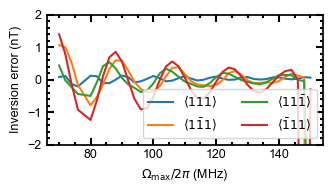

In [15]:
run_fig_6a(B_MAGNITUDE_T=70e-6)

Ideal Rabi frequencies: [85.94 88.12 93.42 91.6 ]
Extracted Rabi frequencies: [85.98 88.24 93.61 91.6 ]
theta = 3.73 deg, phi = 20.05 deg, freq domain errors = [-27.04  -5.37 -52.64  -1.05] nT
	 	 	 time domain fit errors = [-245.533  191.964   56.304 -202.869] nT
Ideal Rabi frequencies: [85.9  88.19 93.44 91.53]
Extracted Rabi frequencies: [85.97 88.29 93.62 91.56]
theta = 3.73 deg, phi = 21.05 deg, freq domain errors = [-35.33   4.11 -52.37 -12.9 ] nT
	 	 	 time domain fit errors = [-269.44   227.349   97.02   -81.11 ] nT
Ideal Rabi frequencies: [85.87 88.26 93.47 91.47]
Extracted Rabi frequencies: [85.95 88.35 93.63 91.51]
theta = 3.73 deg, phi = 22.05 deg, freq domain errors = [-39.4   10.25 -50.89 -26.81] nT
	 	 	 time domain fit errors = [-269.073  243.383  123.572   20.672] nT
Ideal Rabi frequencies: [85.84 88.33 93.49 91.41]
Extracted Rabi frequencies: [85.93 88.41 93.63 91.46]
theta = 3.73 deg, phi = 23.05 deg, freq domain errors = [-39.62  13.4  -48.59 -39.57] nT
	 	 	 time d

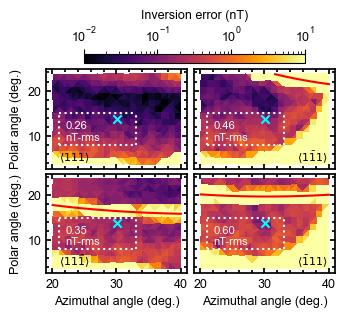

In [4]:
run_fig_6b(b_magnitude_t=70e-6, detuning_hz=0)

### Testing Fig 5 at 10 MHz detuning

#### Plotting routine

In [5]:
import numpy as np
from matplotlib import pyplot as plt
from numpy.typing import NDArray

from bff_paper_figures.shared_parameters import B_PHI_FIG4, B_THETA_FIG4, BASE_PATH, HZ_TO_MHZ, RAD_TO_DEGREE, T_TO_UT

######################################################################################################
# Loads and plots the inversion error vs magnetic field angle (Figure 5). Also does layout and labels.
# The relevant data is generated by simulate_and_invert_vs_b_angle.py, which takes about a day to run.
#######################################################################################################

B_MAGNITUDE_T = 50e-6
# Rabi frequencies for each orientation for the simulation run in simulate_and_invert_vs_b_angle.py
# (used here only as labels for the plots)
RABI_FREQUENCIES = [
    np.float64(66364423.69292802),
    np.float64(79174946.48739058),
    np.float64(92756072.06279232),
    np.float64(85965509.82093404),
]

# Defines the filenames for the data to be plotted.
RUN_LABEL = f"b_{1e6 * B_MAGNITUDE_T:.0f}_ut_t2s_2_us_fine_3us_ramsey_800ns_rabi"


# Calculates the rms error within theta_range = [theta_min, theta_max] and phi_range = [phi_min, phi_max]
# for the specified orientation.
# errors_nt[i] is the error calculated for all four orientations at phi_values[i], theta_values[i].
def get_rms_error_within_range(
    theta_range: list,
    phi_range: list,
    phi_values: NDArray,
    theta_values: NDArray,
    errors_nt: NDArray,
    orientation: int,
) -> float:
    masks = np.array(
        [
            theta_values * 360 / (2 * np.pi) < theta_range[1],
            theta_values * 360 / (2 * np.pi) > theta_range[0],
            phi_values * 360 / (2 * np.pi) < phi_range[1],
            phi_values * 360 / (2 * np.pi) > phi_range[0],
        ]
    )
    mask = np.all(masks, axis=0)
    errors_nt_masked = errors_nt[mask]
    return np.sqrt(np.mean(errors_nt_masked[:, orientation] ** 2))


# Plots the error in extracted transition frequency (expressed as equivalent axial field)
# as a function of the magnetic field angle.
def plot_errors_vs_b_angle_all_orientations(
    theta_values: NDArray,
    phi_values: NDArray,
    errors_nt: NDArray,
    log_plot: bool = True,
    vmin: float = 0.01,
    vmax: float = 300,
) -> None:
    plotstyle = "log" if log_plot else "linear"

    # Define the labels for each orientation and the positions at which they should be plotted
    nv_axes = [
        r"$\langle111\rangle$",
        r"$\langle1\bar{1}1\rangle$",
        r"$\langle11\bar{1}\rangle$",
        r"$\langle\bar{1}11\rangle$",
    ]
    rabis = [f"{HZ_TO_MHZ * RABI_FREQUENCIES[i]:.0f} MHz" for i in range(len(RABI_FREQUENCIES))]
    nv_axis_positions = [[2, 4], [2, 4], [2, 155], [2, 155]]
    rabi_positions = [[245, 4], [245, 4], [245, 155], [245, 155]]

    # Define the ranges over which we will calculate the RMS error
    theta_ranges = [[90, 180], [90, 180], [0, 90], [0, 90]]
    phi_ranges = [[155, 295], [155 - 90, 295 - 90], [155, 295], [155 - 90, 295 - 90]]

    # Calculate the rms error and define how and where it should be plotted
    errors = [
        get_rms_error_within_range(
            theta_ranges[i],
            phi_ranges[i],
            np.array(phi_values),
            np.array(theta_values),
            np.array(errors_nt),
            i,
        )
        for i in range(4)
    ]
    error_labels = [f"{errors[i]:.2f}\nnT-rms" for i in range(4)]
    error_positions = [[185, 120], [85, 120], [185, 15], [85, 15]]

    # Plot the monstrosity
    plt.rcParams["font.size"] = 9
    plt.rcParams["font.family"] = "arial"
    fig, axes = plt.subplots(nrows=2, ncols=2, sharex=True, sharey=True)
    fig.set_figheight(3)
    fig.set_figwidth(3.4)

    for i, ax in enumerate(axes.flat):
        im = ax.tripcolor(
            np.array(phi_values) * RAD_TO_DEGREE,
            np.array(theta_values) * RAD_TO_DEGREE,
            np.abs(np.array(errors_nt)[:, i]),
            cmap="inferno",
            norm=plotstyle,
            vmin=vmin,
            vmax=vmax,
        )
        # Plot the angular location of the field used in Fig. 4 and 6
        if i == 3:
            ax.scatter(B_PHI_FIG4 * RAD_TO_DEGREE, B_THETA_FIG4 * RAD_TO_DEGREE, marker="x", color="cyan")
        if i == 2 or i == 3:
            ax.set_xlabel("Azimuthal angle (deg.)", fontsize=9)
        if i == 0 or i == 2:
            ax.set_ylabel("Polar angle (deg.)", fontsize=9)

        # Beautify the ticks
        ax.yaxis.set_ticks_position("both")
        ax.xaxis.set_ticks_position("both")
        ax.minorticks_on()
        ax.tick_params(direction="in", which="both", width=1.25)
        ax.tick_params(direction="in", which="minor", length=2)
        ax.tick_params(direction="in", which="major", length=3.5)
        for spine in ax.spines.values():
            spine.set_linewidth(1.25)

        # Add in labels and rms errors
        ax.text(nv_axis_positions[i][0], nv_axis_positions[i][1], nv_axes[i], color="white", fontsize=8)
        ax.text(rabi_positions[i][0], rabi_positions[i][1], rabis[i], color="white", fontsize=8)
        ax.text(error_positions[i][0], error_positions[i][1], error_labels[i], color="white", fontsize=8)
        ax.vlines(phi_ranges[i], [theta_ranges[i][0]], [theta_ranges[i][1]], linestyle="dotted", color="white")
        ax.hlines(theta_ranges[i], [phi_ranges[i][0]], [phi_ranges[i][1]], linestyle="dotted", color="white")

        # Plot the zero-axial-field contour for one of the orientations
        if i == 1:
            phi_range_full = np.linspace(0, 2 * np.pi, 101)
            theta_no_projection = np.atan2(1, np.sin(phi_range_full) - np.cos(phi_range_full))
            ax.plot(
                phi_range_full * RAD_TO_DEGREE, theta_no_projection * RAD_TO_DEGREE, color="white", linestyle="dashdot"
            )

    # Adjust spacing
    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    plt.subplots_adjust(top=0.8, right=0.99, left=0.14, bottom=0.12)

    # Add a shared colorbar
    cbar_ax = fig.add_axes([0.25, 0.82, 0.65, 0.03])
    cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
    cbar.set_label(f"Inversion error (nT) at {T_TO_UT * B_MAGNITUDE_T:.0f} uT", fontsize=9)
    cbar.ax.xaxis.set_label_position("top")
    cbar.ax.xaxis.set_ticks_position("top")

#### Detuning = 10 MHz

theta = 0.00, phi = 0.00, freq domain errors = [-45.24 -37.97 -31.93 -35.03] nT
	 	 	 time domain fit errors = [0.196 0.153 0.141 0.147] nT
theta = 0.00, phi = 3.14, freq domain errors = [-45.24 -37.97 -31.93 -35.03] nT
	 	 	 time domain fit errors = [0.196 0.153 0.141 0.147] nT
theta = 0.00, phi = 6.28, freq domain errors = [-45.24 -37.97 -31.93 -35.03] nT
	 	 	 time domain fit errors = [0.196 0.153 0.141 0.147] nT
theta = 0.31, phi = 0.00, freq domain errors = [-24.75  -8.38 -13.33 -15.11] nT
	 	 	 time domain fit errors = [ 0.048 -0.25   0.135  0.403] nT
theta = 0.31, phi = 1.26, freq domain errors = [-194.79  -16.27  -13.07  -40.63] nT
	 	 	 time domain fit errors = [-0.036  0.718  0.428 -0.928] nT
theta = 0.31, phi = 2.51, freq domain errors = [ -33.58   -9.91  -37.99 -100.51] nT
	 	 	 time domain fit errors = [-0.189  0.478  0.308  0.472] nT
theta = 0.31, phi = 3.77, freq domain errors = [-14.2  -28.32 -90.33 -41.43] nT
	 	 	 time domain fit errors = [ 0.316 -0.243 -0.386  0.54 ]

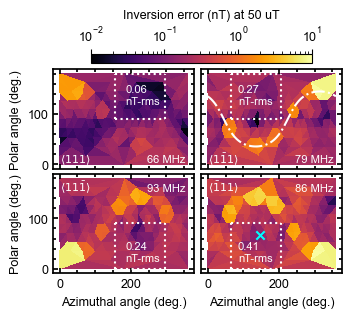

In [8]:
from math import floor

import numpy as np
from matplotlib import pyplot as plt
from bff_paper_figures.Figure5_inversion import plot_errors_vs_b_angle_all_orientations
from bff_paper_figures.extract_experiment_values import get_ideal_rabi_frequencies, get_true_transition_frequencies
from bff_paper_figures.fitting_routines import (
    extract_fit_centers_all_orientations,
    fit_vs_eigenvalue_error_all_orientations_nt,
)
from bff_paper_figures.inner_product_functions import InnerProductSettings
from bff_paper_figures.inversions import (
    freq_domain_inversion,
    time_domain_inversion,
)
from bff_paper_figures.simulation_helper_functions import angles_already_evaluated, sq_cancelled_signal_generator
from bff_simulator.abstract_classes.abstract_ensemble import NVOrientation
from bff_simulator.constants import NVaxes_100, exy
from bff_simulator.homogeneous_ensemble import HomogeneousEnsemble
from bff_simulator.liouvillian_solver import LiouvillianSolver
from bff_simulator.offaxis_field_experiment_parameters import OffAxisFieldExperimentParametersFactory
from bff_paper_figures.shared_parameters import T_TO_UT, MW_DIRECTION, E_FIELD_VECTOR_V_PER_CM, RABI_FREQ_BASE_HZ, DETUNING_HZ, RAMSEY_FREQ_RANGE_INITIAL_GUESS_HZ, T2STAR_S, PEAK_INDEX

B_MAGNITUDE_T = 50e-6
B_THETA_START = 0
B_THETA_STOP = np.pi
B_THETA_N = 11

B_PHI_START = 0
B_PHI_STOP = 2 * np.pi
B_PHI_N_MAX = 21
B_PHI_N_MIN = 3

MW_PULSE_LENGTH_S = np.arange(0, 800e-9, 2.5e-9)  # np.linspace(0, 0.5e-6, 1001)
EVOLUTION_TIME_S = np.arange(0, 3e-6, 20e-9)  # p.linspace(0, 15e-6, 801)

RUN_LABEL = f"det_10_mhz_b_{B_MAGNITUDE_T * T_TO_UT:.0f}_ut_t2s_{T2STAR_S * 1e6:.0f}_us_fine_3us_ramsey_800ns_rabi"
detuning_hz = 1e5
nv_ensemble = HomogeneousEnsemble()
nv_ensemble.t2_star_s = T2STAR_S
nv_ensemble.add_full_diamond_populations()

off_axis_solver = LiouvillianSolver()

exp_param_factory = OffAxisFieldExperimentParametersFactory()
exp_param_factory.set_base_rabi_frequency(RABI_FREQ_BASE_HZ)
exp_param_factory.set_mw_direction(MW_DIRECTION)
exp_param_factory.set_e_field_v_per_m(E_FIELD_VECTOR_V_PER_CM)
exp_param_factory.set_detuning(detuning_hz)
exp_param_factory.set_mw_pulse_lengths(MW_PULSE_LENGTH_S)
exp_param_factory.set_evolution_times(EVOLUTION_TIME_S)

inner_product_settings = InnerProductSettings(
    MW_PULSE_LENGTH_S,
    EVOLUTION_TIME_S,
    rabi_window="blackman",
    ramsey_window="boxcar",
    subtract_mean=True,
    use_effective_rabi_frequency=True,
)

ideal_rabi_frequencies = get_ideal_rabi_frequencies(exp_param_factory.get_experiment_parameters())

theta_values = []
phi_values = []
errors_vs_b_freq_domain_nt = []
errors_vs_b_time_domain_nt = []

# Optinally load a partially completed simulation
# errors_vs_b_freq_domain_nt = list(np.loadtxt(f"errors_nt_freq_{RUN_LABEL}.txt"))
# errors_vs_b_time_domain_nt = list(np.loadtxt(f"errors_nt_time_{RUN_LABEL}.txt", ))
# phi_values = list(np.loadtxt(f"phi_values_{RUN_LABEL}.txt"))
# theta_values = list(np.loadtxt(f"theta_values_{RUN_LABEL}.txt"))

problem_theta_values = []
problem_phi_values = []

for theta in np.linspace(B_THETA_START, B_THETA_STOP, B_THETA_N):
    b_phi_n = max(B_PHI_N_MIN, floor(np.sin(theta) * B_PHI_N_MAX))
    for phi in np.linspace(B_PHI_START, B_PHI_STOP, b_phi_n):
        if not angles_already_evaluated(theta, phi, theta_values, phi_values):
            b_field_vector_t = B_MAGNITUDE_T * np.array(
                [np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)]
            )
            exp_param_factory.set_b_field_vector(b_field_vector_t)
            sq_cancelled_signal = sq_cancelled_signal_generator(exp_param_factory, nv_ensemble, off_axis_solver)

            larmor_freqs_all_axes_hz, bz_values_all_axes_t = get_true_transition_frequencies(
                exp_param_factory.get_experiment_parameters()
            )
            ideal_rabi_frequencies = get_ideal_rabi_frequencies(exp_param_factory.get_experiment_parameters())
            rabi_frequencies = find_rabi_frequencies_from_signal(sq_cancelled_signal, inner_product_settings)
            try:
                # frequency domain inversion
                peakfit_results = freq_domain_inversion(
                    sq_cancelled_signal,
                    rabi_frequencies,
                    inner_product_settings,
                    RAMSEY_FREQ_RANGE_INITIAL_GUESS_HZ,
                    T2STAR_S,
                    constrain_same_width=True,
                    allow_zero_peak=True,
                )
                errors_fd_nt = fit_vs_eigenvalue_error_all_orientations_nt(peakfit_results, larmor_freqs_all_axes_hz)
                print(
                    f"theta = {theta:.2f}, phi = {phi:.2f}, freq domain errors = {np.array2string(errors_fd_nt[:, PEAK_INDEX], precision=2)} nT"
                )

                # time domain inversion using the ideal rabi frequencies and initial guesses from frequency domain inversion
                freq_guesses_all_orientations = extract_fit_centers_all_orientations(peakfit_results)
                time_domain_fit_results = time_domain_inversion(
                    sq_cancelled_signal,
                    rabi_frequencies,
                    inner_product_settings,
                    freq_guesses_all_orientations,
                    T2STAR_S,
                    fix_phase_to_zero=False,
                    constrain_same_decay=True,
                    constrain_hyperfine_freqs=True,
                )
                errors_td_nt = fit_vs_eigenvalue_error_all_orientations_nt(
                    time_domain_fit_results, larmor_freqs_all_axes_hz
                )
                print(
                    f"\t \t \t time domain fit errors = {np.array2string(errors_td_nt[:, PEAK_INDEX], precision=3)} nT"
                )

                errors_vs_b_freq_domain_nt.append(errors_fd_nt[:, PEAK_INDEX])
                errors_vs_b_time_domain_nt.append(errors_td_nt[:, PEAK_INDEX])
                theta_values.append(theta)
                phi_values.append(phi)
            except ValueError:
                print(f"theta = {theta:.8f}, phi = {phi:.8f} generated ValueError ")
                problem_theta_values.append(theta)
                problem_phi_values.append(phi)

plot_errors_vs_b_angle_all_orientations(
    theta_values, phi_values, errors_vs_b_time_domain_nt, log_plot=True, vmin=0.01, vmax=10
)
plt.show()

#### Detuning = 0 MHz

theta = 0.00, phi = 0.00, freq domain errors = [-45.4  -38.11 -32.05 -35.13] nT
	 	 	 time domain fit errors = [0.005 0.004 0.004 0.004] nT
theta = 0.00, phi = 3.14, freq domain errors = [-45.4  -38.11 -32.05 -35.13] nT
	 	 	 time domain fit errors = [0.005 0.004 0.004 0.004] nT
theta = 0.00, phi = 6.28, freq domain errors = [-45.4  -38.11 -32.05 -35.13] nT
	 	 	 time domain fit errors = [0.005 0.004 0.004 0.004] nT
theta = 0.31, phi = 0.00, freq domain errors = [-24.7   -8.35 -13.33 -15.11] nT
	 	 	 time domain fit errors = [ 0.053 -0.258 -0.018  0.239] nT
theta = 0.31, phi = 1.26, freq domain errors = [-195.74  -16.3   -13.11  -40.62] nT
	 	 	 time domain fit errors = [-0.054  0.485  0.258 -0.859] nT
theta = 0.31, phi = 2.51, freq domain errors = [ -33.45   -9.95  -38.11 -100.53] nT
	 	 	 time domain fit errors = [-0.081  0.291  0.321  0.438] nT
theta = 0.31, phi = 3.77, freq domain errors = [-14.27 -28.2  -90.35 -41.49] nT
	 	 	 time domain fit errors = [ 0.077 -0.146 -0.424  0.52 ]

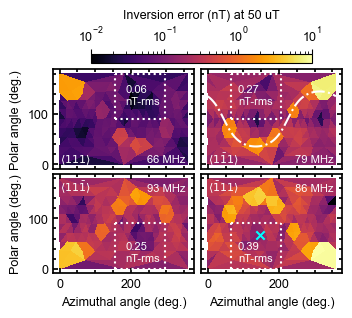

In [9]:
from math import floor

import numpy as np
from matplotlib import pyplot as plt
from bff_paper_figures.Figure5_inversion import plot_errors_vs_b_angle_all_orientations
from bff_paper_figures.extract_experiment_values import get_ideal_rabi_frequencies, get_true_transition_frequencies
from bff_paper_figures.fitting_routines import (
    extract_fit_centers_all_orientations,
    fit_vs_eigenvalue_error_all_orientations_nt,
)
from bff_paper_figures.inner_product_functions import InnerProductSettings
from bff_paper_figures.inversions import (
    freq_domain_inversion,
    time_domain_inversion,
)
from bff_paper_figures.simulation_helper_functions import angles_already_evaluated, sq_cancelled_signal_generator
from bff_simulator.abstract_classes.abstract_ensemble import NVOrientation
from bff_simulator.constants import NVaxes_100, exy
from bff_simulator.homogeneous_ensemble import HomogeneousEnsemble
from bff_simulator.liouvillian_solver import LiouvillianSolver
from bff_simulator.offaxis_field_experiment_parameters import OffAxisFieldExperimentParametersFactory
from bff_paper_figures.shared_parameters import T_TO_UT, MW_DIRECTION, E_FIELD_VECTOR_V_PER_CM, RABI_FREQ_BASE_HZ, DETUNING_HZ, RAMSEY_FREQ_RANGE_INITIAL_GUESS_HZ, T2STAR_S, PEAK_INDEX

B_MAGNITUDE_T = 50e-6
B_THETA_START = 0
B_THETA_STOP = np.pi
B_THETA_N = 11

B_PHI_START = 0
B_PHI_STOP = 2 * np.pi
B_PHI_N_MAX = 21
B_PHI_N_MIN = 3

MW_PULSE_LENGTH_S = np.arange(0, 800e-9, 2.5e-9)  # np.linspace(0, 0.5e-6, 1001)
EVOLUTION_TIME_S = np.arange(0, 3e-6, 20e-9)  # p.linspace(0, 15e-6, 801)

RUN_LABEL = f"det_0_mhz_b_{B_MAGNITUDE_T * T_TO_UT:.0f}_ut_t2s_{T2STAR_S * 1e6:.0f}_us_fine_3us_ramsey_800ns_rabi"
detuning_hz = 0
nv_ensemble = HomogeneousEnsemble()
nv_ensemble.t2_star_s = T2STAR_S
nv_ensemble.add_full_diamond_populations()

off_axis_solver = LiouvillianSolver()

exp_param_factory = OffAxisFieldExperimentParametersFactory()
exp_param_factory.set_base_rabi_frequency(RABI_FREQ_BASE_HZ)
exp_param_factory.set_mw_direction(MW_DIRECTION)
exp_param_factory.set_e_field_v_per_m(E_FIELD_VECTOR_V_PER_CM)
exp_param_factory.set_detuning(detuning_hz)
exp_param_factory.set_mw_pulse_lengths(MW_PULSE_LENGTH_S)
exp_param_factory.set_evolution_times(EVOLUTION_TIME_S)

inner_product_settings = InnerProductSettings(
    MW_PULSE_LENGTH_S,
    EVOLUTION_TIME_S,
    rabi_window="blackman",
    ramsey_window="boxcar",
    subtract_mean=True,
    use_effective_rabi_frequency=True,
)

ideal_rabi_frequencies = get_ideal_rabi_frequencies(exp_param_factory.get_experiment_parameters())

theta_values = []
phi_values = []
errors_vs_b_freq_domain_nt = []
errors_vs_b_time_domain_nt = []

# Optinally load a partially completed simulation
# errors_vs_b_freq_domain_nt = list(np.loadtxt(f"errors_nt_freq_{RUN_LABEL}.txt"))
# errors_vs_b_time_domain_nt = list(np.loadtxt(f"errors_nt_time_{RUN_LABEL}.txt", ))
# phi_values = list(np.loadtxt(f"phi_values_{RUN_LABEL}.txt"))
# theta_values = list(np.loadtxt(f"theta_values_{RUN_LABEL}.txt"))

problem_theta_values = []
problem_phi_values = []

for theta in np.linspace(B_THETA_START, B_THETA_STOP, B_THETA_N):
    b_phi_n = max(B_PHI_N_MIN, floor(np.sin(theta) * B_PHI_N_MAX))
    for phi in np.linspace(B_PHI_START, B_PHI_STOP, b_phi_n):
        if not angles_already_evaluated(theta, phi, theta_values, phi_values):
            b_field_vector_t = B_MAGNITUDE_T * np.array(
                [np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)]
            )
            exp_param_factory.set_b_field_vector(b_field_vector_t)
            sq_cancelled_signal = sq_cancelled_signal_generator(exp_param_factory, nv_ensemble, off_axis_solver)

            larmor_freqs_all_axes_hz, bz_values_all_axes_t = get_true_transition_frequencies(
                exp_param_factory.get_experiment_parameters()
            )
            rabi_frequencies = find_rabi_frequencies_from_signal(sq_cancelled_signal, inner_product_settings)
            try:
                # frequency domain inversion
                peakfit_results = freq_domain_inversion(
                    sq_cancelled_signal,
                    rabi_frequencies,
                    inner_product_settings,
                    RAMSEY_FREQ_RANGE_INITIAL_GUESS_HZ,
                    T2STAR_S,
                    constrain_same_width=True,
                    allow_zero_peak=True,
                )
                errors_fd_nt = fit_vs_eigenvalue_error_all_orientations_nt(peakfit_results, larmor_freqs_all_axes_hz)
                print(
                    f"theta = {theta:.2f}, phi = {phi:.2f}, freq domain errors = {np.array2string(errors_fd_nt[:, PEAK_INDEX], precision=2)} nT"
                )

                # time domain inversion using the ideal rabi frequencies and initial guesses from frequency domain inversion
                freq_guesses_all_orientations = extract_fit_centers_all_orientations(peakfit_results)
                time_domain_fit_results = time_domain_inversion(
                    sq_cancelled_signal,
                    rabi_frequencies,
                    inner_product_settings,
                    freq_guesses_all_orientations,
                    T2STAR_S,
                    fix_phase_to_zero=False,
                    constrain_same_decay=True,
                    constrain_hyperfine_freqs=True,
                )
                errors_td_nt = fit_vs_eigenvalue_error_all_orientations_nt(
                    time_domain_fit_results, larmor_freqs_all_axes_hz
                )
                print(
                    f"\t \t \t time domain fit errors = {np.array2string(errors_td_nt[:, PEAK_INDEX], precision=3)} nT"
                )

                errors_vs_b_freq_domain_nt.append(errors_fd_nt[:, PEAK_INDEX])
                errors_vs_b_time_domain_nt.append(errors_td_nt[:, PEAK_INDEX])
                theta_values.append(theta)
                phi_values.append(phi)
            except ValueError:
                print(f"theta = {theta:.8f}, phi = {phi:.8f} generated ValueError ")
                problem_theta_values.append(theta)
                problem_phi_values.append(phi)

plot_errors_vs_b_angle_all_orientations(
    theta_values, phi_values, errors_vs_b_time_domain_nt, log_plot=True, vmin=0.01, vmax=10
)
plt.show()

### Tests at 60 MHz Rabi frequency

[39982083.37174756 47646940.46053539 55777490.19021705 51716992.18563562]
theta = 0.00, phi = 0.00, freq domain errors = [-77.31 -66.61 -54.75 -62.1 ] nT
	 	 	 time domain fit errors = [-0.002 -0.002 -0.002 -0.001] nT
[39982083.37174756 47646940.46053539 55777490.19021705 51716992.18563562]
theta = 0.00, phi = 3.14, freq domain errors = [-77.31 -66.61 -54.75 -62.1 ] nT
	 	 	 time domain fit errors = [-0.002 -0.002 -0.002 -0.001] nT
[39982083.37174756 47646940.46053539 55777490.19021705 51716992.18563562]
theta = 0.00, phi = 6.28, freq domain errors = [-77.31 -66.61 -54.75 -62.1 ] nT
	 	 	 time domain fit errors = [-0.002 -0.002 -0.002 -0.001] nT
[39988508.1720033  47654707.11855912 55769789.08376424 51709475.8692528 ]
theta = 0.22, phi = 0.00, freq domain errors = [-105.57  -84.36  -30.99  -37.33] nT
	 	 	 time domain fit errors = [ 0.236  0.534  0.708 -0.717] nT
[39990578.45224985 47641471.60843749 55768449.87281439 51721264.61498635]
theta = 0.22, phi = 1.26, freq domain errors = [-9

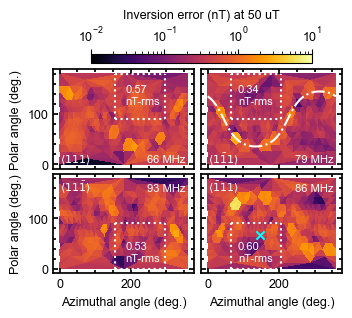

In [18]:
from math import floor

import numpy as np
from matplotlib import pyplot as plt
from bff_paper_figures.Figure5_inversion import plot_errors_vs_b_angle_all_orientations
from bff_paper_figures.extract_experiment_values import get_ideal_rabi_frequencies, get_true_transition_frequencies, find_rabi_frequencies_from_signal
from bff_paper_figures.fitting_routines import (
    extract_fit_centers_all_orientations,
    fit_vs_eigenvalue_error_all_orientations_nt,
)
from bff_paper_figures.inner_product_functions import InnerProductSettings
from bff_paper_figures.inversions import (
    freq_domain_inversion,
    time_domain_inversion,
)
from bff_paper_figures.simulation_helper_functions import angles_already_evaluated, sq_cancelled_signal_generator
from bff_simulator.abstract_classes.abstract_ensemble import NVOrientation
from bff_simulator.constants import NVaxes_100, exy
from bff_simulator.homogeneous_ensemble import HomogeneousEnsemble
from bff_simulator.liouvillian_solver import LiouvillianSolver
from bff_simulator.offaxis_field_experiment_parameters import OffAxisFieldExperimentParametersFactory
from bff_paper_figures.shared_parameters import T_TO_UT, MW_DIRECTION, E_FIELD_VECTOR_V_PER_CM, RABI_FREQ_BASE_HZ, DETUNING_HZ, RAMSEY_FREQ_RANGE_INITIAL_GUESS_HZ, T2STAR_S, PEAK_INDEX

B_MAGNITUDE_T = 50e-6
B_THETA_START = 0
B_THETA_STOP = np.pi
B_THETA_N = 15

B_PHI_START = 0
B_PHI_STOP = 2 * np.pi
B_PHI_N_MAX = 31
B_PHI_N_MIN = 3

MW_PULSE_LENGTH_S = np.arange(0, 800e-9, 2.5e-9)  # np.linspace(0, 0.5e-6, 1001)
EVOLUTION_TIME_S = np.arange(0, 3e-6, 20e-9)  # p.linspace(0, 15e-6, 801)

RABI_FREQ_BASE_HZ = 60e6

HEIGHT_FACTOR = 0.3
PROMINENCE_FACTOR = 0.3
RABI_FREQ_RANGE_TO_PROBE_HZ = np.linspace(30e6, 80e6, 201)

RUN_LABEL = f"det_0_mhz_b_{B_MAGNITUDE_T * T_TO_UT:.0f}_ut_t2s_{T2STAR_S * 1e6:.0f}_us_fine_3us_ramsey_800ns_rabi"
detuning_hz = 0
nv_ensemble = HomogeneousEnsemble()
nv_ensemble.t2_star_s = T2STAR_S
nv_ensemble.add_full_diamond_populations()

off_axis_solver = LiouvillianSolver()

exp_param_factory = OffAxisFieldExperimentParametersFactory()
exp_param_factory.set_base_rabi_frequency(RABI_FREQ_BASE_HZ)
exp_param_factory.set_mw_direction(MW_DIRECTION)
exp_param_factory.set_e_field_v_per_m(E_FIELD_VECTOR_V_PER_CM)
exp_param_factory.set_detuning(detuning_hz)
exp_param_factory.set_mw_pulse_lengths(MW_PULSE_LENGTH_S)
exp_param_factory.set_evolution_times(EVOLUTION_TIME_S)

inner_product_settings = InnerProductSettings(
    MW_PULSE_LENGTH_S,
    EVOLUTION_TIME_S,
    rabi_window="blackman",
    ramsey_window="boxcar",
    subtract_mean=True,
    use_effective_rabi_frequency=True,
)

ideal_rabi_frequencies = get_ideal_rabi_frequencies(exp_param_factory.get_experiment_parameters())

theta_values = []
phi_values = []
errors_vs_b_freq_domain_nt = []
errors_vs_b_time_domain_nt = []

# Optinally load a partially completed simulation
# errors_vs_b_freq_domain_nt = list(np.loadtxt(f"errors_nt_freq_{RUN_LABEL}.txt"))
# errors_vs_b_time_domain_nt = list(np.loadtxt(f"errors_nt_time_{RUN_LABEL}.txt", ))
# phi_values = list(np.loadtxt(f"phi_values_{RUN_LABEL}.txt"))
# theta_values = list(np.loadtxt(f"theta_values_{RUN_LABEL}.txt"))

problem_theta_values = []
problem_phi_values = []

for theta in np.linspace(B_THETA_START, B_THETA_STOP, B_THETA_N):
    b_phi_n = max(B_PHI_N_MIN, floor(np.sin(theta) * B_PHI_N_MAX))
    for phi in np.linspace(B_PHI_START, B_PHI_STOP, b_phi_n):
        if not angles_already_evaluated(theta, phi, theta_values, phi_values):
            b_field_vector_t = B_MAGNITUDE_T * np.array(
                [np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)]
            )
            exp_param_factory.set_b_field_vector(b_field_vector_t)
            sq_cancelled_signal = sq_cancelled_signal_generator(exp_param_factory, nv_ensemble, off_axis_solver)

            larmor_freqs_all_axes_hz, bz_values_all_axes_t = get_true_transition_frequencies(
                exp_param_factory.get_experiment_parameters()
            )
            rabi_frequencies = find_rabi_frequencies_from_signal(
                sq_cancelled_signal,
                inner_product_settings,
                rabi_freq_range_to_probe_hz=RABI_FREQ_RANGE_TO_PROBE_HZ,
                height_factor=HEIGHT_FACTOR,
                prominence_factor=PROMINENCE_FACTOR,
                use_time_domain_summation_for_initial_guesses=False,
            )
            print(rabi_frequencies)
            #rabi_frequencies = ideal_rabi_frequencies
            try:
                # frequency domain inversion
                peakfit_results = freq_domain_inversion(
                    sq_cancelled_signal,
                    rabi_frequencies,
                    inner_product_settings,
                    RAMSEY_FREQ_RANGE_INITIAL_GUESS_HZ,
                    T2STAR_S,
                    constrain_same_width=True,
                    allow_zero_peak=True,
                )
                errors_fd_nt = fit_vs_eigenvalue_error_all_orientations_nt(peakfit_results, larmor_freqs_all_axes_hz)
                print(
                    f"theta = {theta:.2f}, phi = {phi:.2f}, freq domain errors = {np.array2string(errors_fd_nt[:, PEAK_INDEX], precision=2)} nT"
                )

                # time domain inversion using the ideal rabi frequencies and initial guesses from frequency domain inversion
                freq_guesses_all_orientations = extract_fit_centers_all_orientations(peakfit_results)
                time_domain_fit_results = time_domain_inversion(
                    sq_cancelled_signal,
                    rabi_frequencies,
                    inner_product_settings,
                    freq_guesses_all_orientations,
                    T2STAR_S,
                    fix_phase_to_zero=False,
                    constrain_same_decay=True,
                    constrain_hyperfine_freqs=False,
                )
                errors_td_nt = fit_vs_eigenvalue_error_all_orientations_nt(
                    time_domain_fit_results, larmor_freqs_all_axes_hz
                )
                print(
                    f"\t \t \t time domain fit errors = {np.array2string(errors_td_nt[:, PEAK_INDEX], precision=3)} nT"
                )

                errors_vs_b_freq_domain_nt.append(errors_fd_nt[:, PEAK_INDEX])
                errors_vs_b_time_domain_nt.append(errors_td_nt[:, PEAK_INDEX])
                theta_values.append(theta)
                phi_values.append(phi)
            except ValueError:
                print(f"theta = {theta:.8f}, phi = {phi:.8f} generated ValueError ")
                problem_theta_values.append(theta)
                problem_phi_values.append(phi)

plot_errors_vs_b_angle_all_orientations(
    theta_values, phi_values, errors_vs_b_time_domain_nt, log_plot=True, vmin=0.01, vmax=10
)
plt.savefig("60MHzRabiFig5.svg")
plt.savefig("60MHzRabiFig5.png", dpi=2000)
plt.show()

### Comparing ideal vs data-extracted rabi frequencies

[66471255.76857954 79268162.7575474  92835804.19751883 86052689.10493304]
theta = 0.00, phi = 0.00, freq domain errors = [-45.4  -38.11 -32.05 -35.13] nT
	 	 	 time domain fit errors = [-0.001 -0.001 -0.001 -0.001] nT
[66471255.76857954 79268162.7575474  92835804.19751883 86052689.10493304]
theta = 0.00, phi = 3.14, freq domain errors = [-45.4  -38.11 -32.05 -35.13] nT
	 	 	 time domain fit errors = [-0.001 -0.001 -0.001 -0.001] nT
[66471255.76857954 79268162.7575474  92835804.19751883 86052689.10493304]
theta = 0.00, phi = 6.28, freq domain errors = [-45.4  -38.11 -32.05 -35.13] nT
	 	 	 time domain fit errors = [-0.001 -0.001 -0.001 -0.001] nT
[66478436.84195752 79274303.54254824 92830114.17740968 86046740.63133048]
theta = 0.22, phi = 0.00, freq domain errors = [-58.89 -48.49  -9.74 -11.91] nT
	 	 	 time domain fit errors = [0.038 0.021 0.069 0.291] nT
[66480790.84568214 79263845.71608362 92829076.22029908 86056083.67663327]
theta = 0.22, phi = 1.26, freq domain errors = [-33.74 -26

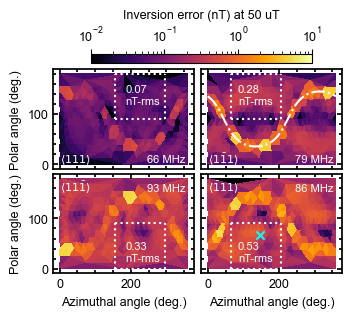

In [21]:
from math import floor

import numpy as np
from matplotlib import pyplot as plt
from bff_paper_figures.Figure5_inversion import plot_errors_vs_b_angle_all_orientations
from bff_paper_figures.extract_experiment_values import get_ideal_rabi_frequencies, get_true_transition_frequencies, find_rabi_frequencies_from_signal
from bff_paper_figures.fitting_routines import (
    extract_fit_centers_all_orientations,
    fit_vs_eigenvalue_error_all_orientations_nt,
)
from bff_paper_figures.inner_product_functions import InnerProductSettings
from bff_paper_figures.inversions import (
    freq_domain_inversion,
    time_domain_inversion,
)
from bff_paper_figures.simulation_helper_functions import angles_already_evaluated, sq_cancelled_signal_generator
from bff_simulator.abstract_classes.abstract_ensemble import NVOrientation
from bff_simulator.constants import NVaxes_100, exy
from bff_simulator.homogeneous_ensemble import HomogeneousEnsemble
from bff_simulator.liouvillian_solver import LiouvillianSolver
from bff_simulator.offaxis_field_experiment_parameters import OffAxisFieldExperimentParametersFactory
from bff_paper_figures.shared_parameters import T_TO_UT, MW_DIRECTION, E_FIELD_VECTOR_V_PER_CM, RABI_FREQ_BASE_HZ, DETUNING_HZ, RAMSEY_FREQ_RANGE_INITIAL_GUESS_HZ, T2STAR_S, PEAK_INDEX

B_MAGNITUDE_T = 50e-6
B_THETA_START = 0
B_THETA_STOP = np.pi
B_THETA_N = 15

B_PHI_START = 0
B_PHI_STOP = 2 * np.pi
B_PHI_N_MAX = 31
B_PHI_N_MIN = 3

MW_PULSE_LENGTH_S = np.arange(0, 800e-9, 2.5e-9)  # np.linspace(0, 0.5e-6, 1001)
EVOLUTION_TIME_S = np.arange(0, 3e-6, 20e-9)  # p.linspace(0, 15e-6, 801)

RABI_FREQ_BASE_HZ = 100e6

HEIGHT_FACTOR = 0.3
PROMINENCE_FACTOR = 0.3
RABI_FREQ_RANGE_TO_PROBE_HZ = np.linspace(50e6, 110e6, 201)

RUN_LABEL = f"det_0_mhz_b_{B_MAGNITUDE_T * T_TO_UT:.0f}_ut_t2s_{T2STAR_S * 1e6:.0f}_us_fine_3us_ramsey_800ns_rabi"
detuning_hz = 0
nv_ensemble = HomogeneousEnsemble()
nv_ensemble.t2_star_s = T2STAR_S
nv_ensemble.add_full_diamond_populations()

off_axis_solver = LiouvillianSolver()

exp_param_factory = OffAxisFieldExperimentParametersFactory()
exp_param_factory.set_base_rabi_frequency(RABI_FREQ_BASE_HZ)
exp_param_factory.set_mw_direction(MW_DIRECTION)
exp_param_factory.set_e_field_v_per_m(E_FIELD_VECTOR_V_PER_CM)
exp_param_factory.set_detuning(detuning_hz)
exp_param_factory.set_mw_pulse_lengths(MW_PULSE_LENGTH_S)
exp_param_factory.set_evolution_times(EVOLUTION_TIME_S)

inner_product_settings = InnerProductSettings(
    MW_PULSE_LENGTH_S,
    EVOLUTION_TIME_S,
    rabi_window="blackman",
    ramsey_window="boxcar",
    subtract_mean=True,
    use_effective_rabi_frequency=True,
)

ideal_rabi_frequencies = get_ideal_rabi_frequencies(exp_param_factory.get_experiment_parameters())

theta_values = []
phi_values = []
errors_vs_b_freq_domain_nt = []
errors_vs_b_time_domain_nt = []

# Optinally load a partially completed simulation
# errors_vs_b_freq_domain_nt = list(np.loadtxt(f"errors_nt_freq_{RUN_LABEL}.txt"))
# errors_vs_b_time_domain_nt = list(np.loadtxt(f"errors_nt_time_{RUN_LABEL}.txt", ))
# phi_values = list(np.loadtxt(f"phi_values_{RUN_LABEL}.txt"))
# theta_values = list(np.loadtxt(f"theta_values_{RUN_LABEL}.txt"))

problem_theta_values = []
problem_phi_values = []

for theta in np.linspace(B_THETA_START, B_THETA_STOP, B_THETA_N):
    b_phi_n = max(B_PHI_N_MIN, floor(np.sin(theta) * B_PHI_N_MAX))
    for phi in np.linspace(B_PHI_START, B_PHI_STOP, b_phi_n):
        if not angles_already_evaluated(theta, phi, theta_values, phi_values):
            b_field_vector_t = B_MAGNITUDE_T * np.array(
                [np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)]
            )
            exp_param_factory.set_b_field_vector(b_field_vector_t)
            sq_cancelled_signal = sq_cancelled_signal_generator(exp_param_factory, nv_ensemble, off_axis_solver)

            larmor_freqs_all_axes_hz, bz_values_all_axes_t = get_true_transition_frequencies(
                exp_param_factory.get_experiment_parameters()
            )
            rabi_frequencies = find_rabi_frequencies_from_signal(
                sq_cancelled_signal,
                inner_product_settings,
                rabi_freq_range_to_probe_hz=RABI_FREQ_RANGE_TO_PROBE_HZ,
                height_factor=HEIGHT_FACTOR,
                prominence_factor=PROMINENCE_FACTOR,
                use_time_domain_summation_for_initial_guesses=False,
            )
            print(rabi_frequencies)
            #rabi_frequencies = ideal_rabi_frequencies
            try:
                # frequency domain inversion
                peakfit_results = freq_domain_inversion(
                    sq_cancelled_signal,
                    rabi_frequencies,
                    inner_product_settings,
                    RAMSEY_FREQ_RANGE_INITIAL_GUESS_HZ,
                    T2STAR_S,
                    constrain_same_width=True,
                    allow_zero_peak=True,
                )
                errors_fd_nt = fit_vs_eigenvalue_error_all_orientations_nt(peakfit_results, larmor_freqs_all_axes_hz)
                print(
                    f"theta = {theta:.2f}, phi = {phi:.2f}, freq domain errors = {np.array2string(errors_fd_nt[:, PEAK_INDEX], precision=2)} nT"
                )

                # time domain inversion using the ideal rabi frequencies and initial guesses from frequency domain inversion
                freq_guesses_all_orientations = extract_fit_centers_all_orientations(peakfit_results)
                time_domain_fit_results = time_domain_inversion(
                    sq_cancelled_signal,
                    rabi_frequencies,
                    inner_product_settings,
                    freq_guesses_all_orientations,
                    T2STAR_S,
                    fix_phase_to_zero=False,
                    constrain_same_decay=True,
                    constrain_hyperfine_freqs=False,
                )
                errors_td_nt = fit_vs_eigenvalue_error_all_orientations_nt(
                    time_domain_fit_results, larmor_freqs_all_axes_hz
                )
                print(
                    f"\t \t \t time domain fit errors = {np.array2string(errors_td_nt[:, PEAK_INDEX], precision=3)} nT"
                )

                errors_vs_b_freq_domain_nt.append(errors_fd_nt[:, PEAK_INDEX])
                errors_vs_b_time_domain_nt.append(errors_td_nt[:, PEAK_INDEX])
                theta_values.append(theta)
                phi_values.append(phi)
            except ValueError:
                print(f"theta = {theta:.8f}, phi = {phi:.8f} generated ValueError ")
                problem_theta_values.append(theta)
                problem_phi_values.append(phi)

plot_errors_vs_b_angle_all_orientations(
    theta_values, phi_values, errors_vs_b_time_domain_nt, log_plot=True, vmin=0.01, vmax=10
)
plt.savefig("60MHzRabiFig5.svg")
plt.savefig("60MHzRabiFig5.png", dpi=2000)
plt.show()

theta = 0.00, phi = 0.00, freq domain errors = [-14.11 -14.63 -14.24 -14.35] nT
	 	 	 time domain fit errors = [-0.003 -0.002 -0.002 -0.002] nT
theta = 0.00, phi = 3.14, freq domain errors = [-14.11 -14.63 -14.24 -14.35] nT
	 	 	 time domain fit errors = [-0.003 -0.002 -0.002 -0.002] nT
theta = 0.00, phi = 6.28, freq domain errors = [-14.11 -14.63 -14.24 -14.35] nT
	 	 	 time domain fit errors = [-0.003 -0.002 -0.002 -0.002] nT
theta = 0.22, phi = 0.00, freq domain errors = [-14.35 -15.21   0.85   0.4 ] nT
	 	 	 time domain fit errors = [0.04  0.223 0.063 0.271] nT
theta = 0.22, phi = 1.26, freq domain errors = [ 31.79  -8.9   -9.59 -26.8 ] nT
	 	 	 time domain fit errors = [-0.015  0.076  0.311 -0.488] nT
theta = 0.22, phi = 2.51, freq domain errors = [-11.25  -7.95 -19.46  29.35] nT
	 	 	 time domain fit errors = [ 0.053 -0.188  0.129 -0.339] nT
theta = 0.22, phi = 3.77, freq domain errors = [ -7.64 -11.58  29.75 -19.26] nT
	 	 	 time domain fit errors = [ 0.126  0.354 -0.507  0.439]

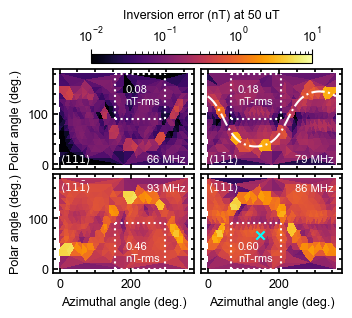

In [22]:
from math import floor

import numpy as np
from matplotlib import pyplot as plt
from bff_paper_figures.Figure5_inversion import plot_errors_vs_b_angle_all_orientations
from bff_paper_figures.extract_experiment_values import get_ideal_rabi_frequencies, get_true_transition_frequencies, find_rabi_frequencies_from_signal
from bff_paper_figures.fitting_routines import (
    extract_fit_centers_all_orientations,
    fit_vs_eigenvalue_error_all_orientations_nt,
)
from bff_paper_figures.inner_product_functions import InnerProductSettings
from bff_paper_figures.inversions import (
    freq_domain_inversion,
    time_domain_inversion,
)
from bff_paper_figures.simulation_helper_functions import angles_already_evaluated, sq_cancelled_signal_generator
from bff_simulator.abstract_classes.abstract_ensemble import NVOrientation
from bff_simulator.constants import NVaxes_100, exy
from bff_simulator.homogeneous_ensemble import HomogeneousEnsemble
from bff_simulator.liouvillian_solver import LiouvillianSolver
from bff_simulator.offaxis_field_experiment_parameters import OffAxisFieldExperimentParametersFactory
from bff_paper_figures.shared_parameters import T_TO_UT, MW_DIRECTION, E_FIELD_VECTOR_V_PER_CM, RABI_FREQ_BASE_HZ, DETUNING_HZ, RAMSEY_FREQ_RANGE_INITIAL_GUESS_HZ, T2STAR_S, PEAK_INDEX

B_MAGNITUDE_T = 50e-6
B_THETA_START = 0
B_THETA_STOP = np.pi
B_THETA_N = 15

B_PHI_START = 0
B_PHI_STOP = 2 * np.pi
B_PHI_N_MAX = 31
B_PHI_N_MIN = 3

MW_PULSE_LENGTH_S = np.arange(0, 800e-9, 2.5e-9)  # np.linspace(0, 0.5e-6, 1001)
EVOLUTION_TIME_S = np.arange(0, 3e-6, 20e-9)  # p.linspace(0, 15e-6, 801)

RABI_FREQ_BASE_HZ = 100e6

HEIGHT_FACTOR = 0.3
PROMINENCE_FACTOR = 0.3
RABI_FREQ_RANGE_TO_PROBE_HZ = np.linspace(50e6, 110e6, 201)

RUN_LABEL = f"det_0_mhz_b_{B_MAGNITUDE_T * T_TO_UT:.0f}_ut_t2s_{T2STAR_S * 1e6:.0f}_us_fine_3us_ramsey_800ns_rabi"
detuning_hz = 0
nv_ensemble = HomogeneousEnsemble()
nv_ensemble.t2_star_s = T2STAR_S
nv_ensemble.add_full_diamond_populations()

off_axis_solver = LiouvillianSolver()

exp_param_factory = OffAxisFieldExperimentParametersFactory()
exp_param_factory.set_base_rabi_frequency(RABI_FREQ_BASE_HZ)
exp_param_factory.set_mw_direction(MW_DIRECTION)
exp_param_factory.set_e_field_v_per_m(E_FIELD_VECTOR_V_PER_CM)
exp_param_factory.set_detuning(detuning_hz)
exp_param_factory.set_mw_pulse_lengths(MW_PULSE_LENGTH_S)
exp_param_factory.set_evolution_times(EVOLUTION_TIME_S)

inner_product_settings = InnerProductSettings(
    MW_PULSE_LENGTH_S,
    EVOLUTION_TIME_S,
    rabi_window="blackman",
    ramsey_window="boxcar",
    subtract_mean=True,
    use_effective_rabi_frequency=True,
)

ideal_rabi_frequencies = get_ideal_rabi_frequencies(exp_param_factory.get_experiment_parameters())

theta_values = []
phi_values = []
errors_vs_b_freq_domain_nt = []
errors_vs_b_time_domain_nt = []

# Optinally load a partially completed simulation
# errors_vs_b_freq_domain_nt = list(np.loadtxt(f"errors_nt_freq_{RUN_LABEL}.txt"))
# errors_vs_b_time_domain_nt = list(np.loadtxt(f"errors_nt_time_{RUN_LABEL}.txt", ))
# phi_values = list(np.loadtxt(f"phi_values_{RUN_LABEL}.txt"))
# theta_values = list(np.loadtxt(f"theta_values_{RUN_LABEL}.txt"))

problem_theta_values = []
problem_phi_values = []

for theta in np.linspace(B_THETA_START, B_THETA_STOP, B_THETA_N):
    b_phi_n = max(B_PHI_N_MIN, floor(np.sin(theta) * B_PHI_N_MAX))
    for phi in np.linspace(B_PHI_START, B_PHI_STOP, b_phi_n):
        if not angles_already_evaluated(theta, phi, theta_values, phi_values):
            b_field_vector_t = B_MAGNITUDE_T * np.array(
                [np.sin(theta) * np.cos(phi), np.sin(theta) * np.sin(phi), np.cos(theta)]
            )
            exp_param_factory.set_b_field_vector(b_field_vector_t)
            sq_cancelled_signal = sq_cancelled_signal_generator(exp_param_factory, nv_ensemble, off_axis_solver)

            larmor_freqs_all_axes_hz, bz_values_all_axes_t = get_true_transition_frequencies(
                exp_param_factory.get_experiment_parameters()
            )
            rabi_frequencies = ideal_rabi_frequencies
            #rabi_frequencies = ideal_rabi_frequencies
            try:
                # frequency domain inversion
                peakfit_results = freq_domain_inversion(
                    sq_cancelled_signal,
                    rabi_frequencies,
                    inner_product_settings,
                    RAMSEY_FREQ_RANGE_INITIAL_GUESS_HZ,
                    T2STAR_S,
                    constrain_same_width=True,
                    allow_zero_peak=True,
                )
                errors_fd_nt = fit_vs_eigenvalue_error_all_orientations_nt(peakfit_results, larmor_freqs_all_axes_hz)
                print(
                    f"theta = {theta:.2f}, phi = {phi:.2f}, freq domain errors = {np.array2string(errors_fd_nt[:, PEAK_INDEX], precision=2)} nT"
                )

                # time domain inversion using the ideal rabi frequencies and initial guesses from frequency domain inversion
                freq_guesses_all_orientations = extract_fit_centers_all_orientations(peakfit_results)
                time_domain_fit_results = time_domain_inversion(
                    sq_cancelled_signal,
                    rabi_frequencies,
                    inner_product_settings,
                    freq_guesses_all_orientations,
                    T2STAR_S,
                    fix_phase_to_zero=False,
                    constrain_same_decay=True,
                    constrain_hyperfine_freqs=False,
                )
                errors_td_nt = fit_vs_eigenvalue_error_all_orientations_nt(
                    time_domain_fit_results, larmor_freqs_all_axes_hz
                )
                print(
                    f"\t \t \t time domain fit errors = {np.array2string(errors_td_nt[:, PEAK_INDEX], precision=3)} nT"
                )

                errors_vs_b_freq_domain_nt.append(errors_fd_nt[:, PEAK_INDEX])
                errors_vs_b_time_domain_nt.append(errors_td_nt[:, PEAK_INDEX])
                theta_values.append(theta)
                phi_values.append(phi)
            except ValueError:
                print(f"theta = {theta:.8f}, phi = {phi:.8f} generated ValueError ")
                problem_theta_values.append(theta)
                problem_phi_values.append(phi)

plot_errors_vs_b_angle_all_orientations(
    theta_values, phi_values, errors_vs_b_time_domain_nt, log_plot=True, vmin=0.01, vmax=10
)
plt.savefig("60MHzRabiFig5.svg")
plt.savefig("60MHzRabiFig5.png", dpi=2000)
plt.show()